# Домашнее задание

### МОВС. 2025-2026

### Анализ временных рядов

__Выдано:__ 02.12.2025

__Срок сдачи:__ 16.12.2025 23:59 MSK

```
Обратите внимание, что если у ассистента возникают подозрения по честному выполнению заданий (плагиат или использование LLM без указания промпта), то он может поставить вам устное собеседование по проделанной работе, по итогам которого он вправе обнулить вам работу.
```

В общем, когда вы читерите, то заставляете в мире плакать одного котенка и одного ассистента. Пожалейте их.

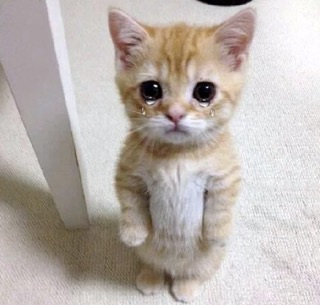

А теперь после такой грозной ноты — к более приятному.

Мы постарались составить домашнее задание так, чтобы оно помогло закрепить все то, что мы прошли на первых занятиях, посвященных классическим методам прогнозирования временных рядов. А также узнать пару новых сюжетов.

Сейчас мы будем работать со сгенерированным временным рядом, истинную форму которого вы не знаете, а мы знаем. Это все равно не значит, что мы будем знать, как построить идеальную модель (потому что в ряде есть артефакты, которые ни ETS-модель, ни SARIMA-модель не смогут до конца хорошо учесть), но мы сможем примерно оценить, а те ли компоненты и свойства ряда вы смогли примерно найти.

В бонусной части вы сможете поработать с реальным рядом и понять, насколько это больнее (а может и нет) :)

Также парочка бонусов будет раскидана по заданиям в основной части. Без бонусов можно набрать максимум 10 баллов, с бонусами — 15. При этом бонусы в сумме дают больше 5 баллов — вы можете выбирать, какие из них делать, а какие нет.

In [1220]:
import random
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from statsmodels.tsa.seasonal import STL
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsforecast.models import AutoETS
from statsforecast import StatsForecast
from statsmodels.tsa.arima.model import ARIMA
from statsforecast.models import AutoARIMA
from pmdarima import auto_arima  




In [1178]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)


seed_everything()

### Задание 1. Первичный анализ данных (1 балл)

Для оценки качества прогнозирования будем использовать метрики MAE и MASE.

`Ответьте на вопрос (0.1 балл):` Что показывает метрика MASE и в чем ее отличие от просто MAE? В каких случаях ее использование предпочтительнее?

Мы уже с вами имплементировали метрики на одном из занятий, так что давайте просто их заберем оттуда.

In [1179]:
def mase(
    forecast: np.ndarray,
    insample: np.ndarray,
    outsample: np.ndarray,
    frequency: int,
) -> np.ndarray:
    """MASE loss as defined in "Scaled Errors" https://robjhyndman.com/papers/mase.pdf

    Args:
        forecast: Forecast values. Shape: batch, time_o
        insample: Insample values. Shape: batch, time_i
        outsample: Target values. Shape: batch, time_o
        frequency: Frequency value
    Returns:
        Same shape array with error calculated for each time step
    """
    return np.mean(np.abs(forecast - outsample)) / np.mean(
        np.abs(insample[:-frequency] - insample[frequency:])
    )


def mae(
    forecast: np.ndarray,
    outsample: np.ndarray,
) -> np.ndarray:
    """MAE (Mean Absolute Error) loss.

    Args:
        forecast: Forecast values. Shape: batch, time_o
        outsample: Target values. Shape: batch, time_o
    Returns:
        MAE value as scalar (np.float64)
    """
    return np.mean(np.abs(forecast - outsample))

#### Задание 1.1: Загрузка данных (0 баллов)

Подгрузите данные из файла `synthetic_ts.csv`.

In [1180]:
# --- Your code here ---
df = pd.read_csv("./synthetic_ts.csv")

#### Задание 1.2: Типы данных (0.05 балла)

Выведите типы данных в датасете. Проверьте, что они корректные: даты должны быть в формате datetime, а значения — float. Если это не так, то исправьте их.

In [1181]:
# --- Your code here ---

print(df.dtypes)
df['date'] = pd.to_datetime(df['date'])
print(df.dtypes)


date     object
y       float64
dtype: object
date    datetime64[ns]
y              float64
dtype: object


#### Задание 1.3: Пропуски (0.05 балла)

Проверьте, есть ли в данных пропуски. Если они есть, то заполните их предыдущими значениями. Если пропусков нет, то просто выведите сообщение об этом.

In [1182]:
# --- Your code here ---
print(df.isna().sum())

date    0
y       0
dtype: int64


#### Задание 1.4: Визуальный анализ временных рядов (0.7 балла)

Постройте линейные графики временного ряда. По оси X отложите время, по оси Y — значения временного ряда.

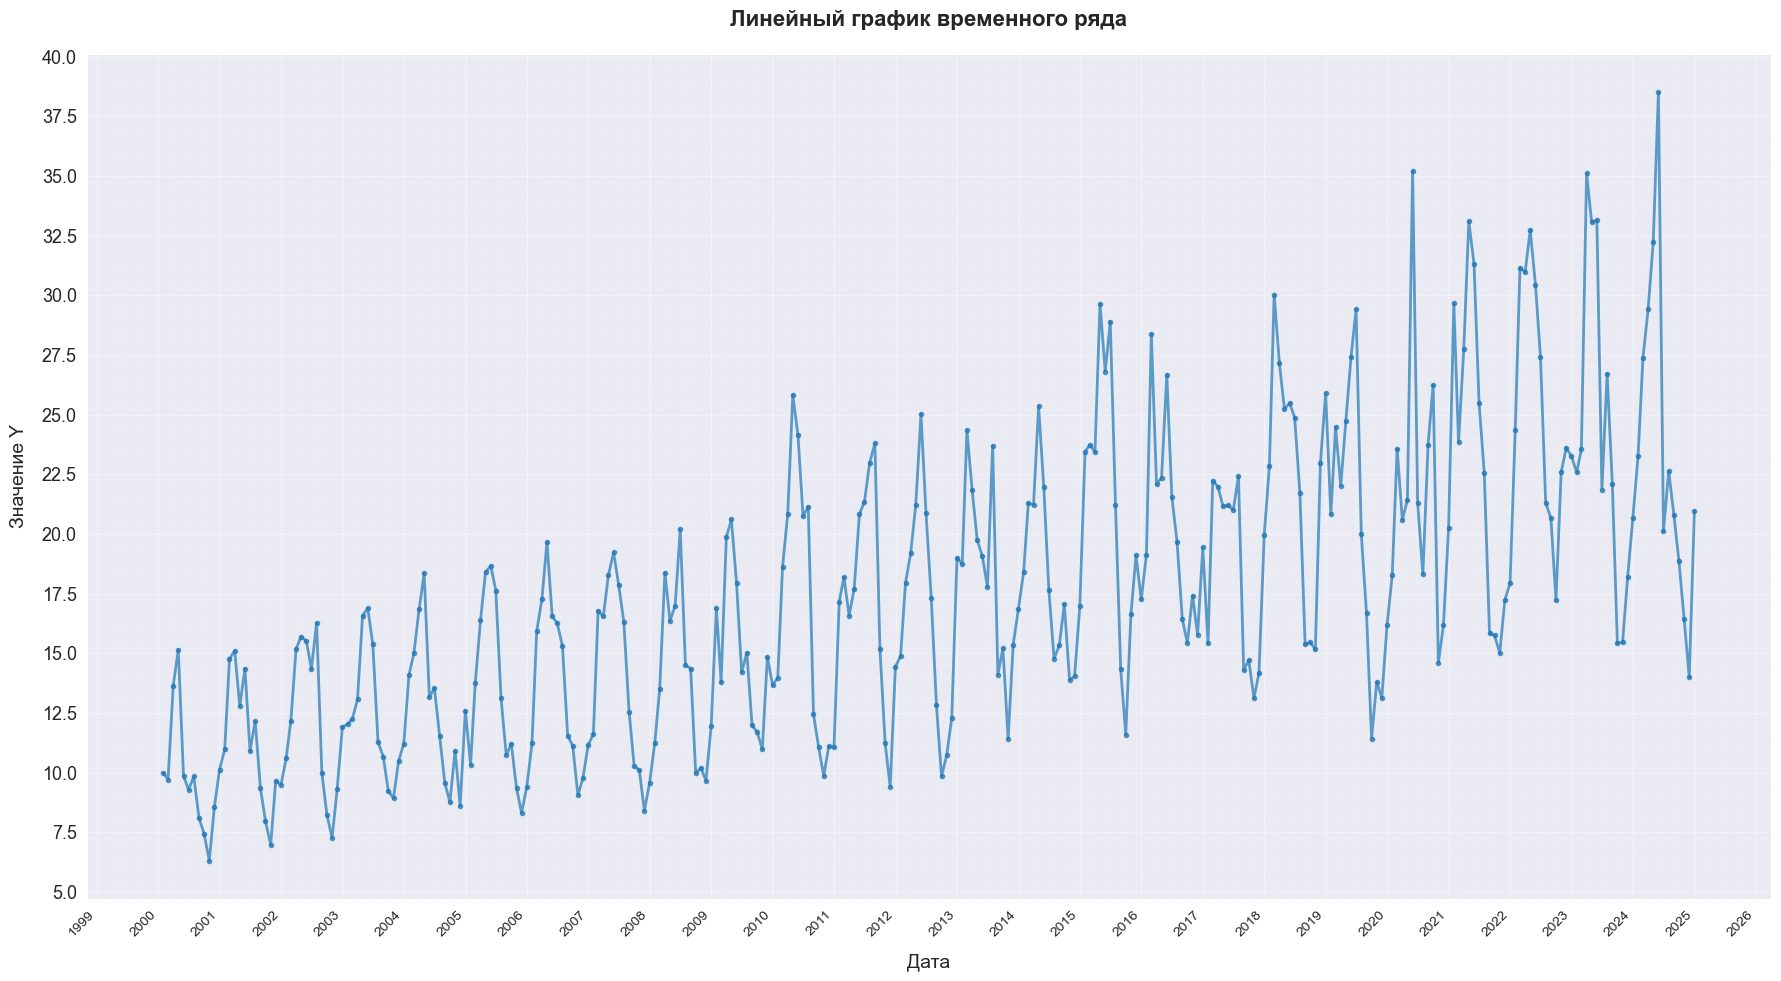

In [1183]:
# --- Your code here ---
%matplotlib inline  

def drawGraphic(x,y,lam=None):
    plt.figure(figsize=(18, 10))
    plt.plot(x, y, linewidth=2, marker='o', markersize=3, alpha=0.7)
    if lam is not None:
        plt.title(f'Линейный график временного ряда (λ = {lam})', 
                  fontsize=16, fontweight='bold', pad=20)
    else:
        plt.title('Линейный график временного ряда', 
                  fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Дата', fontsize=14, labelpad=10)
    plt.ylabel('Значение Y', fontsize=14, labelpad=10)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.minorticks_on()
    plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10, maxticks=40))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=15))
    plt.tight_layout()
    plt.show()
    
drawGraphic(df['date'],df['y'])

#попросил llm сделать красивый график после того как начертил простой


`Ответьте на следующие вопросы:`
- Какова частотность (frequency) данных?
- Стационарен ли временной ряд? Если нет, то какие признаки нестационарности вы можете выделить?

1. Частотность данных - ежемесячные, значения собираются раз в месяц.
2. Ряд не стационарен - среднее значение растет - виден тренд, матожидание не постоянно, разброс данных с каждым значением все больше - значит дисперсия меняется со временем.

Теперь постройте графики [автокорреляций (ACF)](https://www.statsmodels.org/dev/generated/statsmodels.graphics.tsaplots.plot_acf.html) и [частных автокорреляций (PACF)](https://www.statsmodels.org/dev/generated/statsmodels.graphics.tsaplots.plot_pacf.html) до 40-го лага для тренировочной выборки.

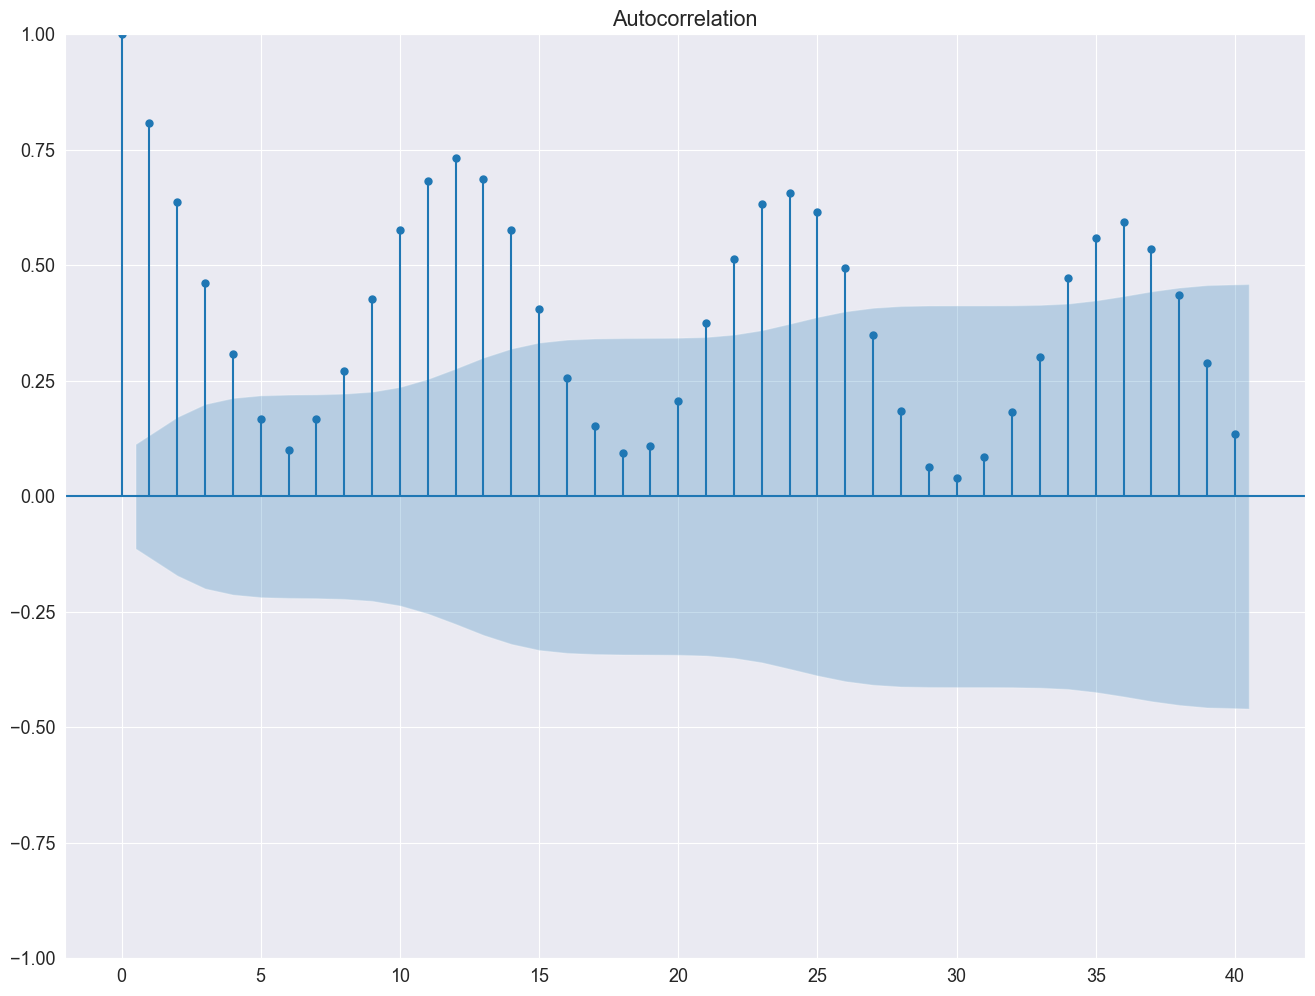

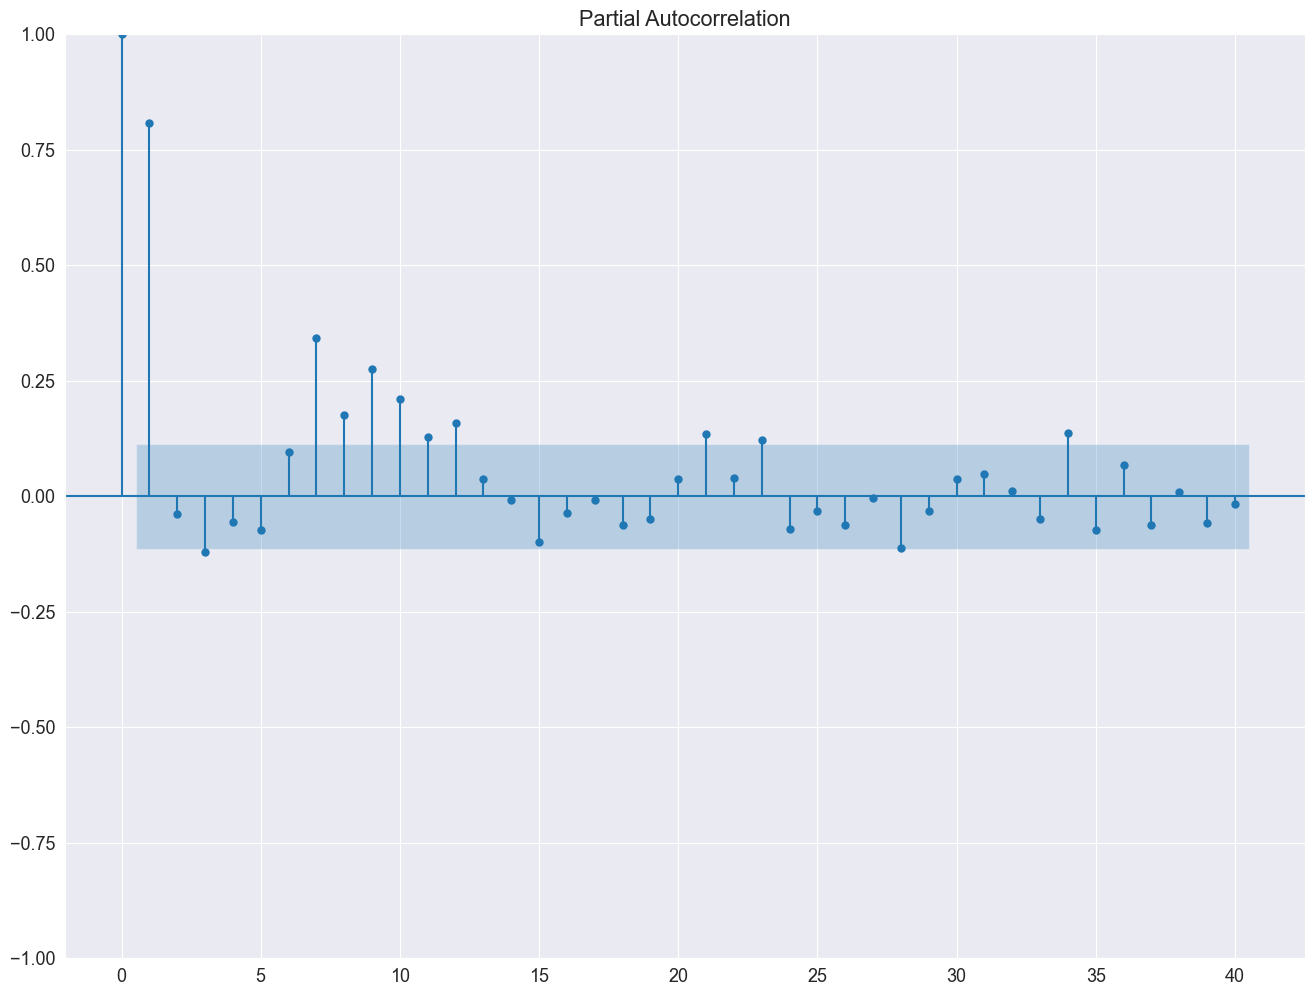

In [1184]:
# --- Your code here ---
plot_acf(df['y'], lags=40)
plt.show()

plot_pacf(df['y'], lags=40)
plt.show()


`Ответьте на следующие вопросы:`
- Стационарен ли временной ряд?
- Присутствует ли в нём тренд? Сезонность? Цикличность?
- Если ряд сезонный, то какой период выглядит наиболее вероятным? Можем ли мы сказать, что сезонность аддитивная? Мультипликативная?

1 - Нет, не стационарен. Видна корреляция значений с сезонностью 12, получаем пики на 1s,2s,3s и 4s. Значения коррелируют между собой. Так как ACF затухает медленно - присутствует тренд.

2 - Да, присутствует тренд и сезонность, цикличности не вижу.
Так как данные взлетают только в пиках по сезонности 1s,2s,3s и 4s.

3 - Период 12, сезонность мультипликативная - так как разброс данных увеличивается

По PACF - 2 значимых лага, потом значения резко падают. Но у нас еще остается тренд тут, оставим для дальнейшего анализа


#### Задание 1.5: Выделение тестовой выборки (0.1 балл)

Выделите 10% данных для теста, а остальные 90% оставьте для обучения.

`Ответьте на вопрос:` В чем особенность выделения тестовой выборки в задаче прогнозирования временных рядов?

In [1185]:
# --- Your code here ---

df_train, df_test = train_test_split(
    df, 
    test_size=0.1,
    shuffle=False,      
    stratify=None     
)

### Задание 2. Стабилизация дисперсии временного ряда (2 балла + 1 бонусный балл)

На одном из занятий мы с вами обсуждали, что для стабилизации дисперсии временного ряда можно использовать преобразование Box-Cox. Давайте разберемся как оно работает. Помним, что Box-Cox нельзя использовать для отрицательных значений, но у нас их и нет.

#### Задание 2.1: Имплементация Box-Cox (1 балл)

Реализуйте прямую и обратную трансформацию Box-Cox (пользоваться готовым решением нельзя!). 

Прямое преобразование Box–Cox:

$$
z = g(y;\lambda) =
\begin{cases}
\dfrac{y^{\lambda} - 1}{\lambda}, & \lambda \ne 0, \\[6pt]
\log y, & \lambda = 0.
\end{cases}
$$

Обратное преобразование Box–Cox:

$$
y = g^{-1}(z;\lambda) =
\begin{cases}
(\lambda z + 1)^{1/\lambda}, & \lambda \ne 0, \\[6pt]
e^{z}, & \lambda = 0.
\end{cases}
$$


`БОНУС (1 балл):` Выведите формулы для обратного преобразования Box-Cox. Можно прикрепить к домашнему заданию файл с решением. Или сюда фотку. Или же ЗаТеХаТь.

In [1186]:
def box_cox(x: np.ndarray, lam: float) -> np.ndarray:
    # --- Your code here ---
    if lam == 0:
            x = np.log(x)
    else:
            x = (np.power(x,lam) - 1)/lam        
    return x
    

def inv_box_cox(y: np.ndarray, lam: float) -> np.ndarray:
    # --- Your code here ---
    if lam == 0:
         y= np.exp(y)
    else:
        y = np.power(lam * y + 1, 1.0 / lam)
        
    return y
    

Проверьте, что `(inv_box_cox(box_cox(x, lam), lam))` примерно восстанавливает исходный массив x.

In [1187]:
# --- Your code here ---
import numpy as np

df_copy = df_train.copy()
lam = 0.5

df_copy['y_transformed'] = box_cox(df_copy['y'].values, lam)
df_copy['y_recovered'] = inv_box_cox(df_copy['y_transformed'], lam)
df_copy['diff'] = np.abs(df_train['y'] - df_copy['y_recovered'])

print("Максимальное отклонение:", df_copy['diff'].max())
print("Все значения совпадают?", np.allclose(df_train['y'], df_copy['y_recovered'], atol=1e-6))


Максимальное отклонение: 3.552713678800501e-15
Все значения совпадают? True


#### Задание 2.2: Подбор параметра λ (1 балл)

Перебор параметры $\lambda$ в боевых условиях происходит с помощью максимизации логарифма правдоподобия ([The optimal lambda parameter for minimizing skewness is estimated on each feature independently using maximum likelihood](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)). 

Но давайте пойдем более простым путем: переберите 3-4 значения $\lambda$ в диапазоне от -2 до 2. Постройте графики полученных рядов и визуально оцените, при каком $\lambda$ дисперсия выглядит наиболее стабильной. 

Переберите еще несколько значений $\lambda$ рядом с тем, которое показалось вам лучшим.

`Ответьте на вопрос:` Как $\lambda$ влияет на вид преобразованного ряда?

$\lambda$ - можно сказать делает распределение ближе к нормальному, чем больше $\lambda$ тем сильнее она сожмет большое значение и увеличит маленькое значение, это способ нормировать значения временных рядов. Делает распределение симметричнее, стабилизует дисперсию.
 
Но есть также крайние случаи - $\lambda$ = 1, преобразование отсутствует. 

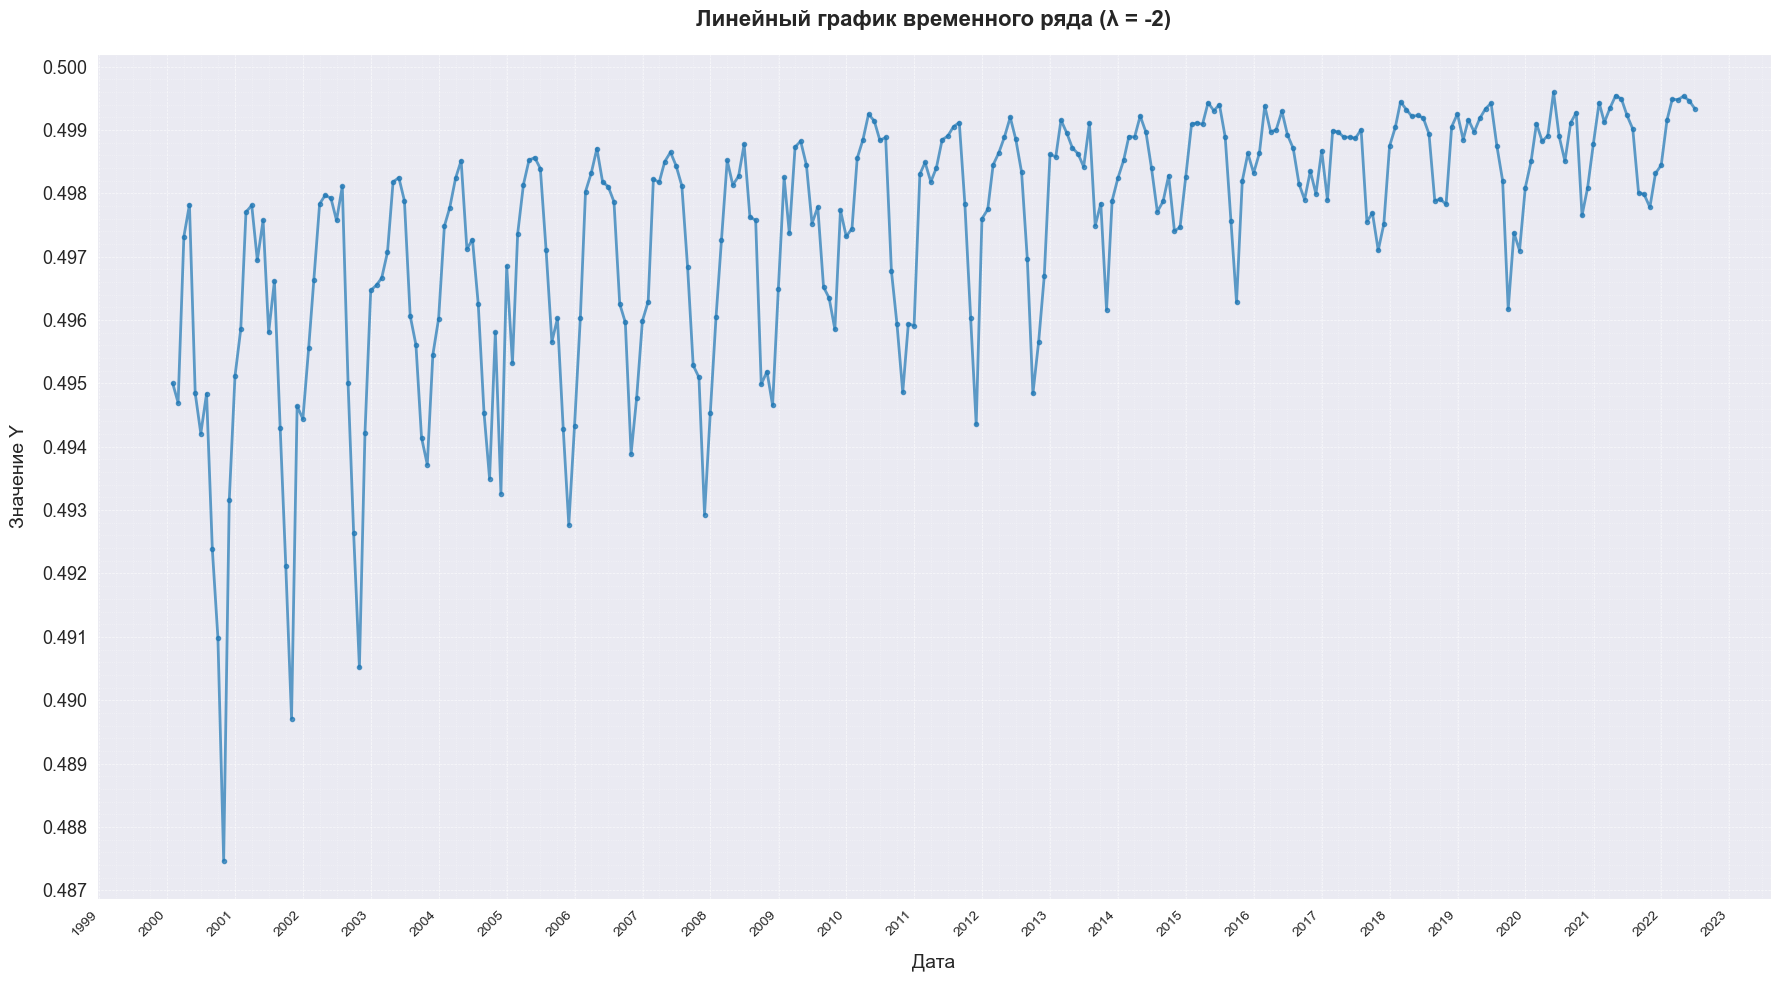

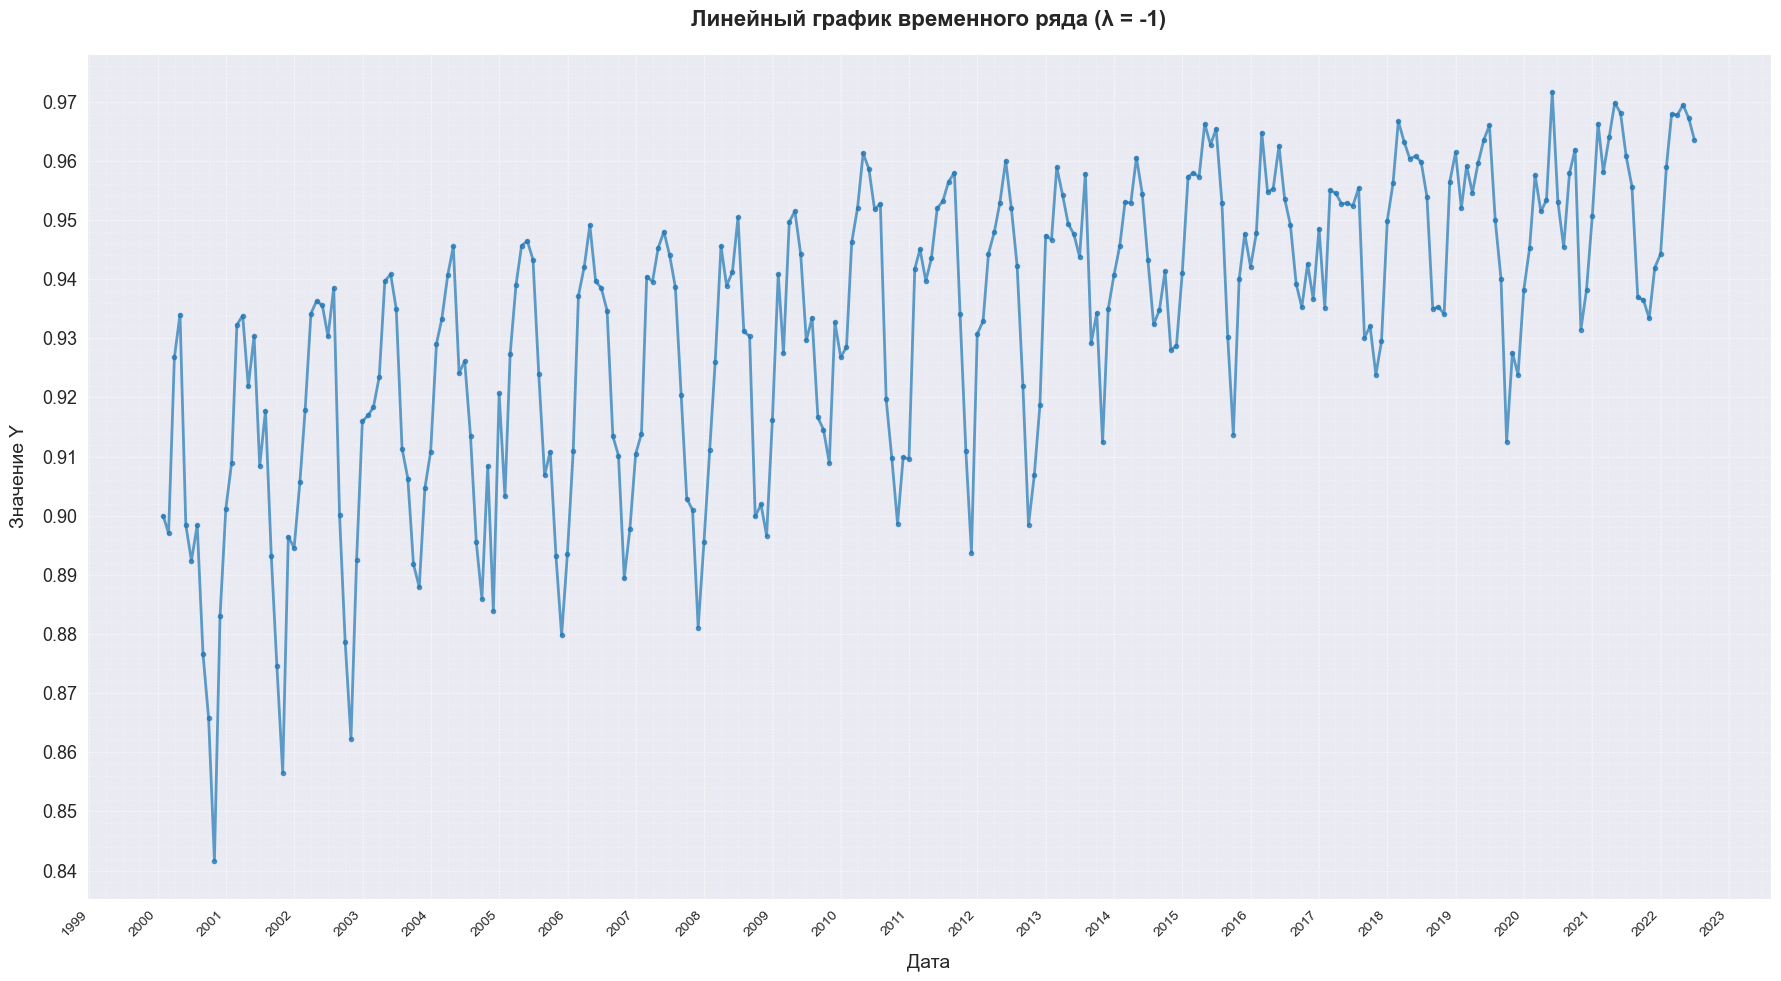

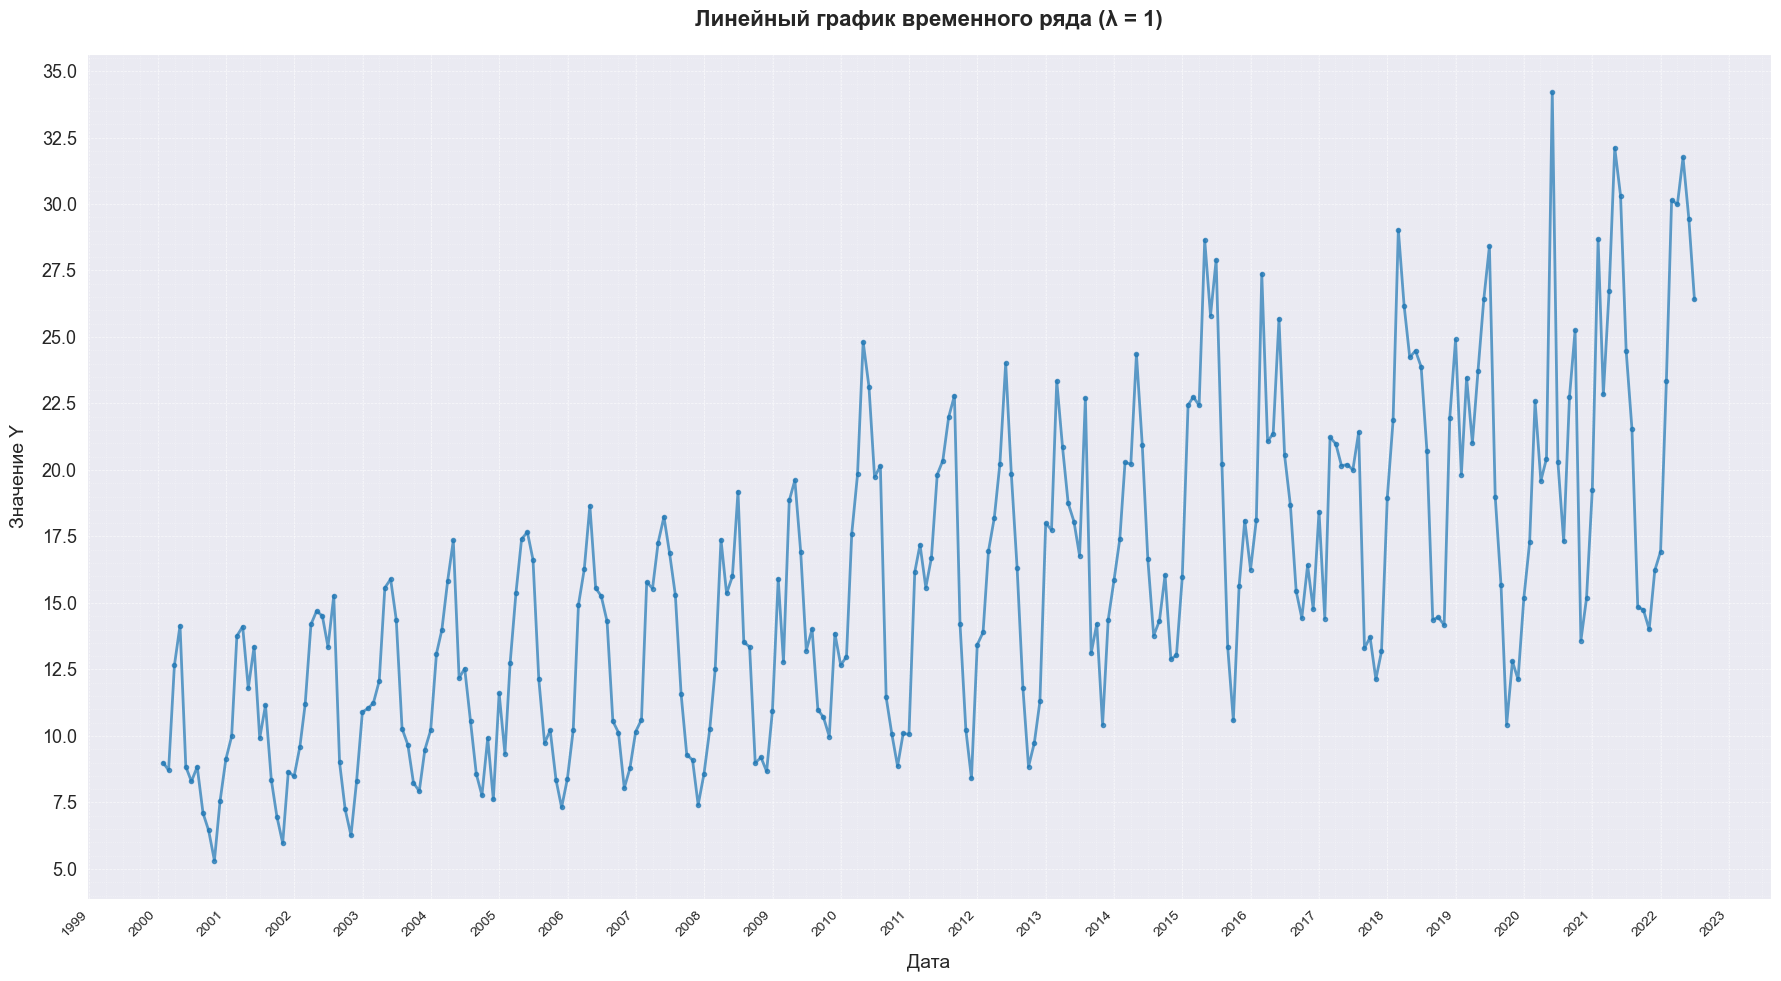

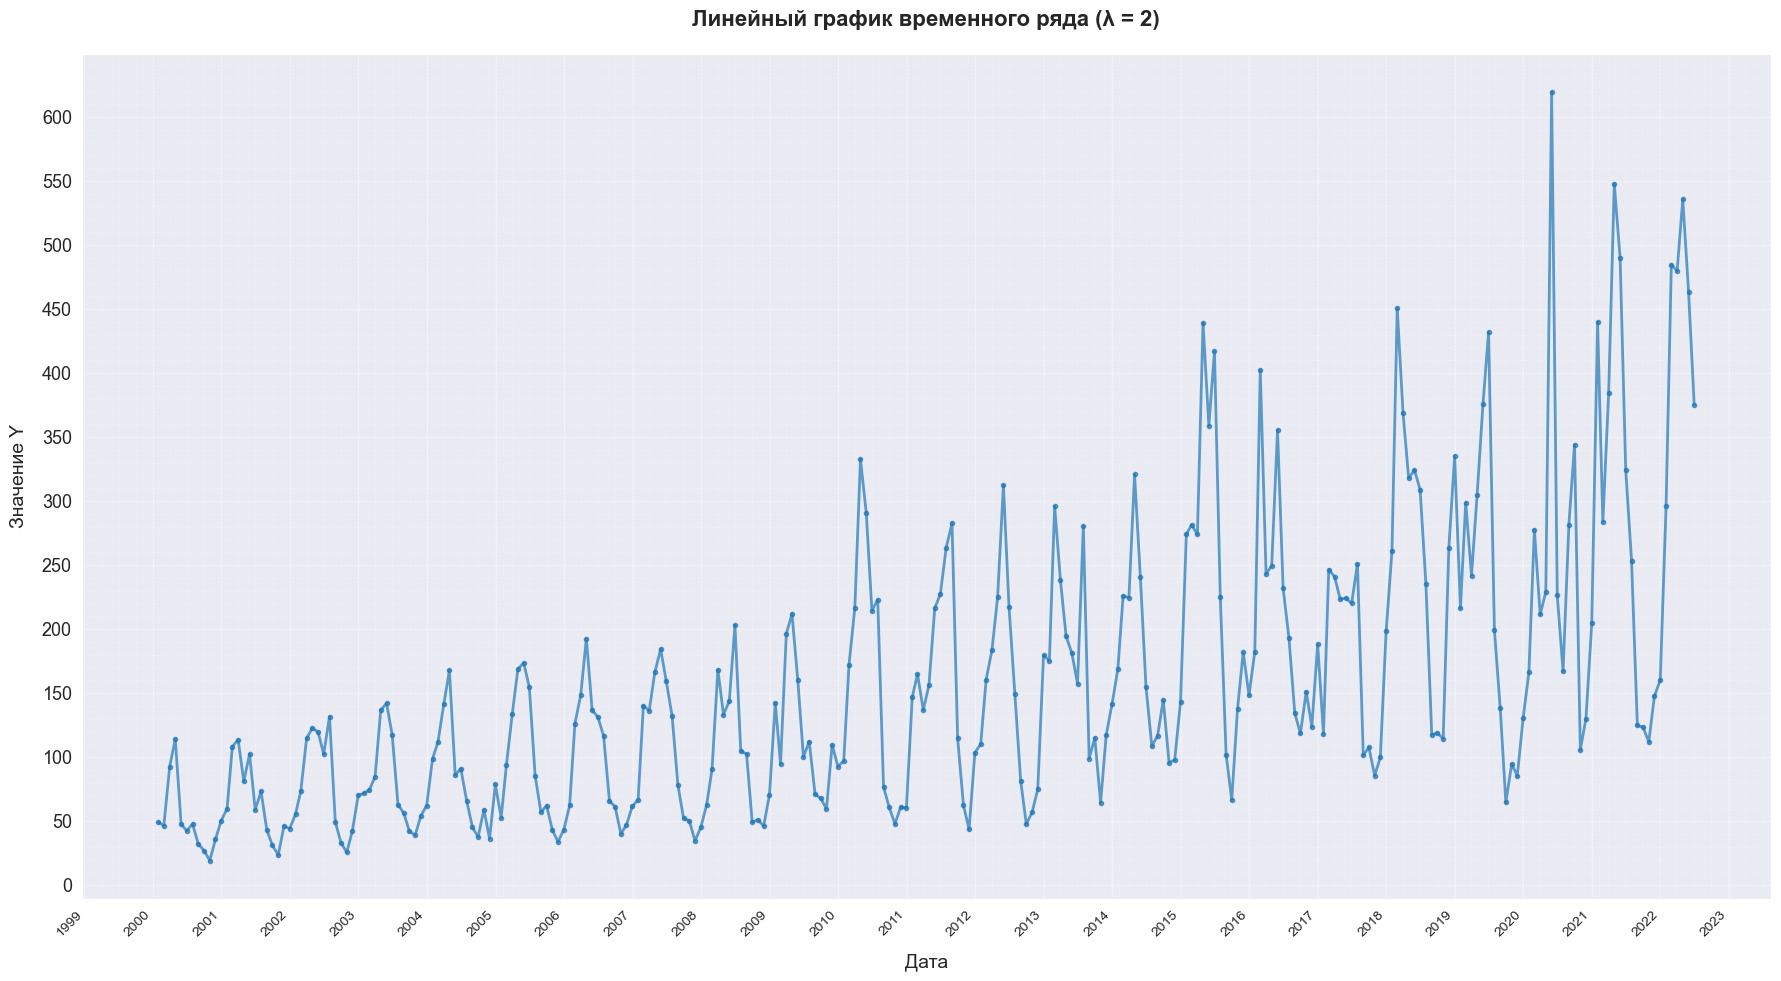

In [1188]:
# --- Your code here ---

lams = [-2,-1,1,2]

for lam in lams:
    df_copy = df_train.copy()
    df_copy['y_transformed'] = box_cox(df_copy['y'].values, lam)
    drawGraphic(df_copy['date'],df_copy['y_transformed'],lam)
    

`Бонус (1 балл):` Предложите и реализуйте автоматический подбор параметра $\lambda$ (не обязательно с помощью максимизации логарифма правдоподобия). Для получения полного балла оно должно показать результат не хуже подобранной $\lambda$ на глаз.

Сохраните для последующих заданий и исходный ряд, и преобразованный рядом с оптимальным $\lambda$.

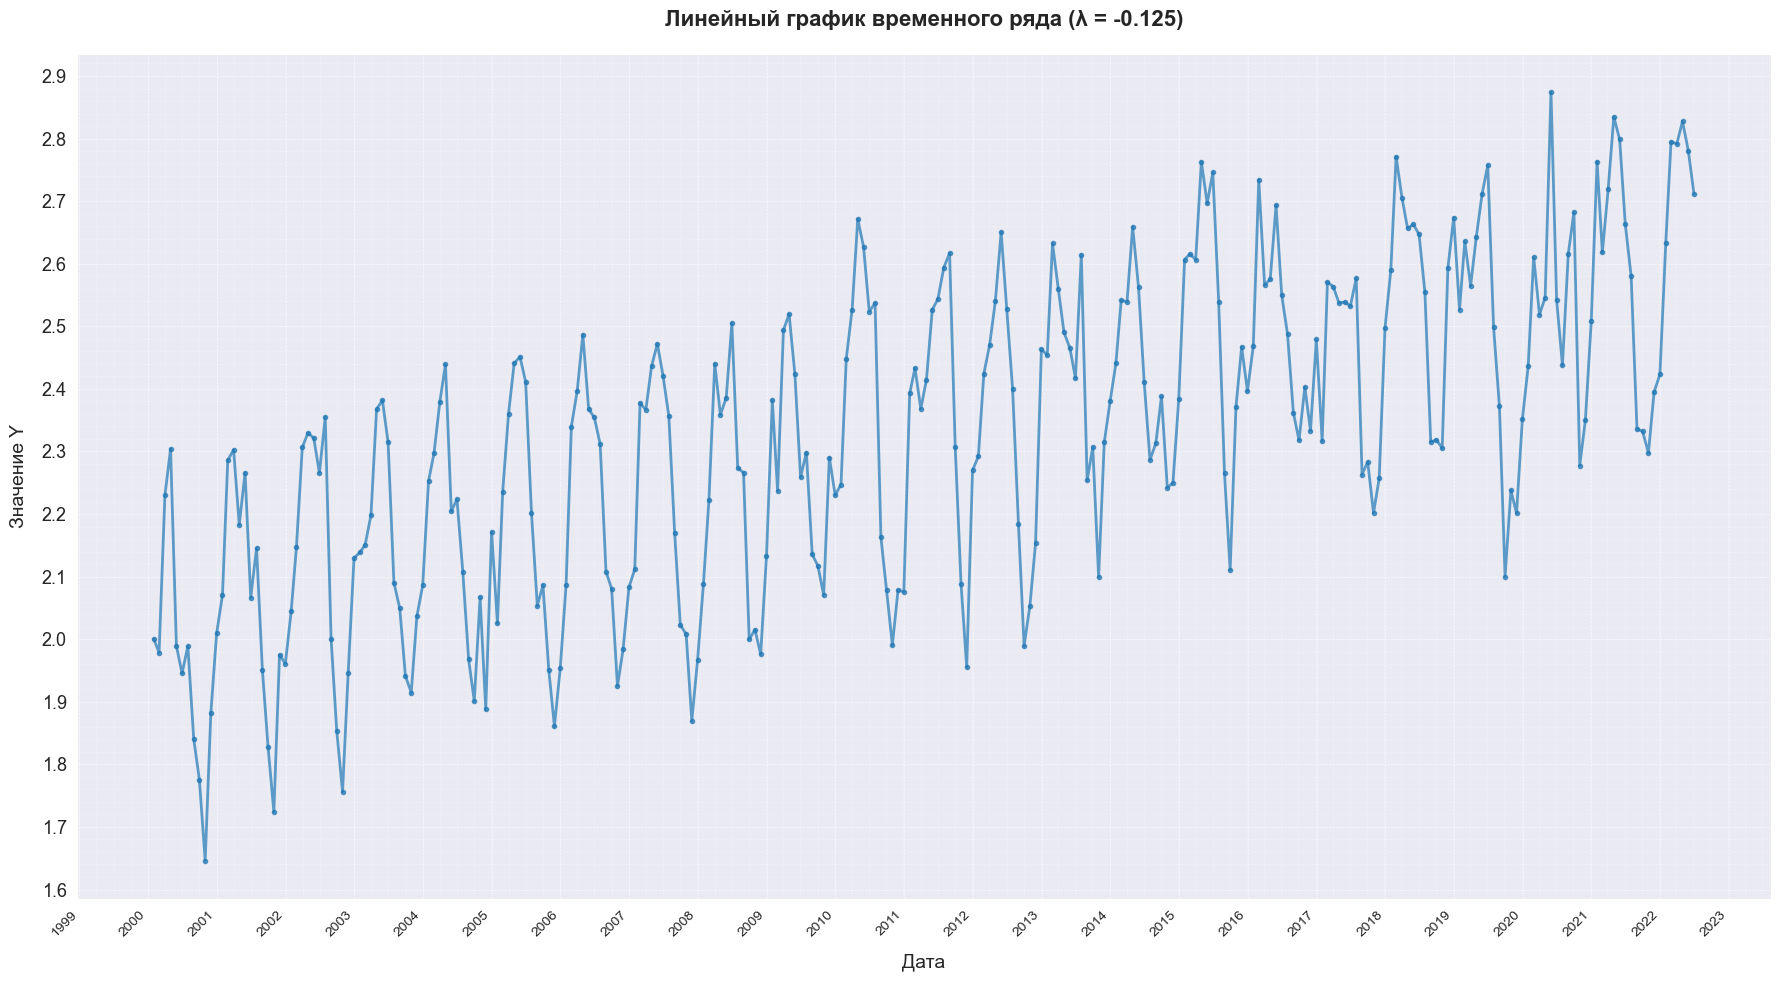

In [1189]:
# --- Your code here ---

#ПОДБИРАЛ РУКАМИ ЛЯМДА 
lam_best = -0.125

df_init = df_train.copy()

df_best_lam = df_train.copy()
df_best_lam['y_transformed'] = box_cox(df_copy['y'].values, lam_best)
drawGraphic(df_best_lam['date'],df_best_lam['y_transformed'], lam_best)
    

### Задание 3. STL + простые модели (1.5 балла)

#### Задание 3.1: STL-декомпозиция (0.5 балла)

Примените STL-декомпозицию к преобразованному ряду, чтобы выделить тренд, сезонность и остатки (здесь можно воспользоваться [готовым методом](https://www.statsmodels.org/dev/examples/notebooks/generated/stl_decomposition.html)).

Постройте графики для каждого из выделенных компонентов. 

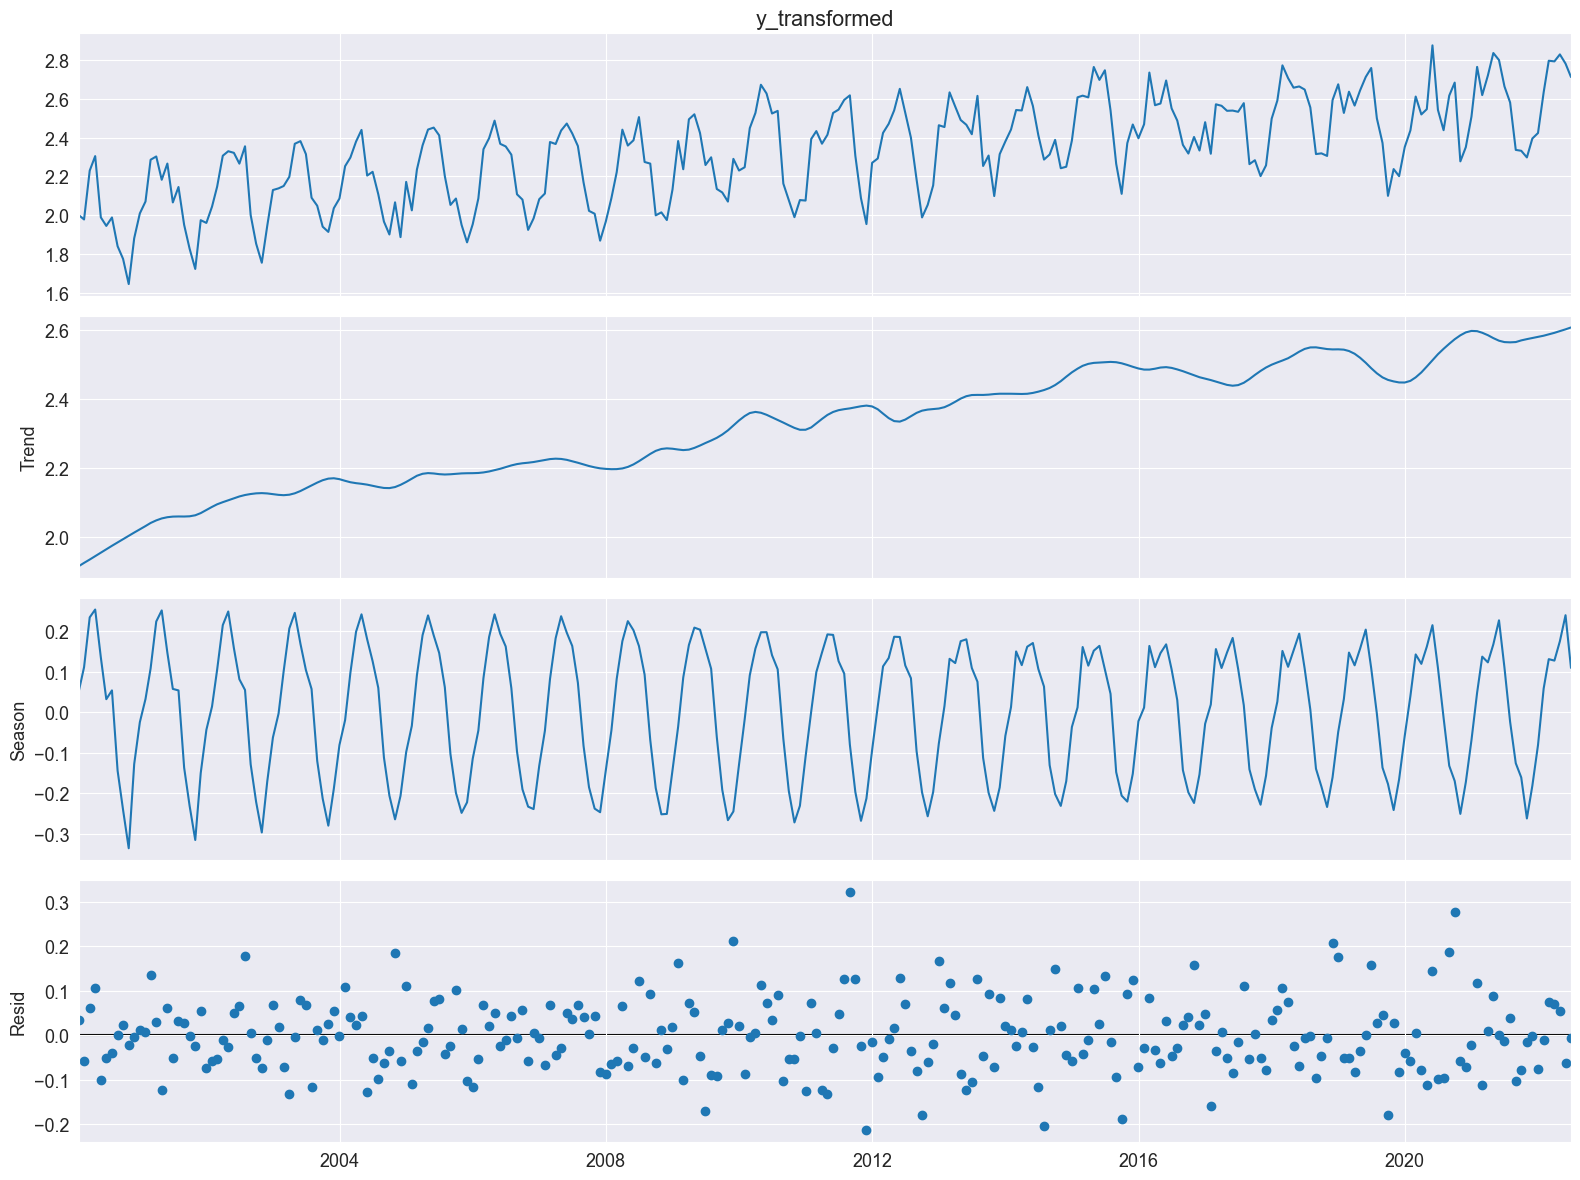

In [1190]:
# --- Your code here ---
register_matplotlib_converters()
sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=13)

df_serie = df_best_lam.set_index('date')['y_transformed']
stl = STL(df_serie, seasonal=13)
res = stl.fit()
fig = res.plot()


`Ответьте на вопросы:` 
- Получилось ли выделить тренд и сезонность? Похожи ли остатки на шум? 

Получилось выделить тренд и сезонность.
Остатки достаточно малы и колеблются около нуля, есть несколько выбросов, которые сильно отличаются от средних. 
В целом, я бы сказал что остатки похожи на шум


Что мы можем сказать о стационарности остатков? Подтвердите соответствующими [тестами](https://www.statsmodels.org/dev/examples/notebooks/generated/stationarity_detrending_adf_kpss.html). Сделайте выводы.

In [1191]:
# --- Your code here ---
residuals = res.resid

def adf_test(series):
    print("Результаты теста ADF:")
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Observations']
    )
    print(dfoutput)

def kpss_test(series):
    print("Результаты теста KPSS:")
    kpsstest = kpss(series, regression='c', nlags='auto')
    kpss_output = pd.Series(
        kpsstest[0:3],
        index=['Test Statistic', 'p-value', 'Lags Used']
    )
    print(kpss_output)


adf_test(residuals)
kpss_test(residuals)



Результаты теста ADF:
Test Statistic   -9.010644e+00
p-value           6.139169e-15
#Lags Used        1.400000e+01
Observations      2.550000e+02
dtype: float64
Результаты теста KPSS:
Test Statistic     0.034995
p-value            0.100000
Lags Used         14.000000
dtype: float64


C:\Users\Albert13\AppData\Local\Temp\ipykernel_4516\2947272310.py:15: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Что мы можем сказать об автокорреляции остатков? Постройте ACF и PACF для остатков. Сделайте выводы.

p-value (ADF) << 0.05 - ряд стационарен по тесту ADF
p-value (ADF) > 0.05 - ряд стационарен по тесту KPSS



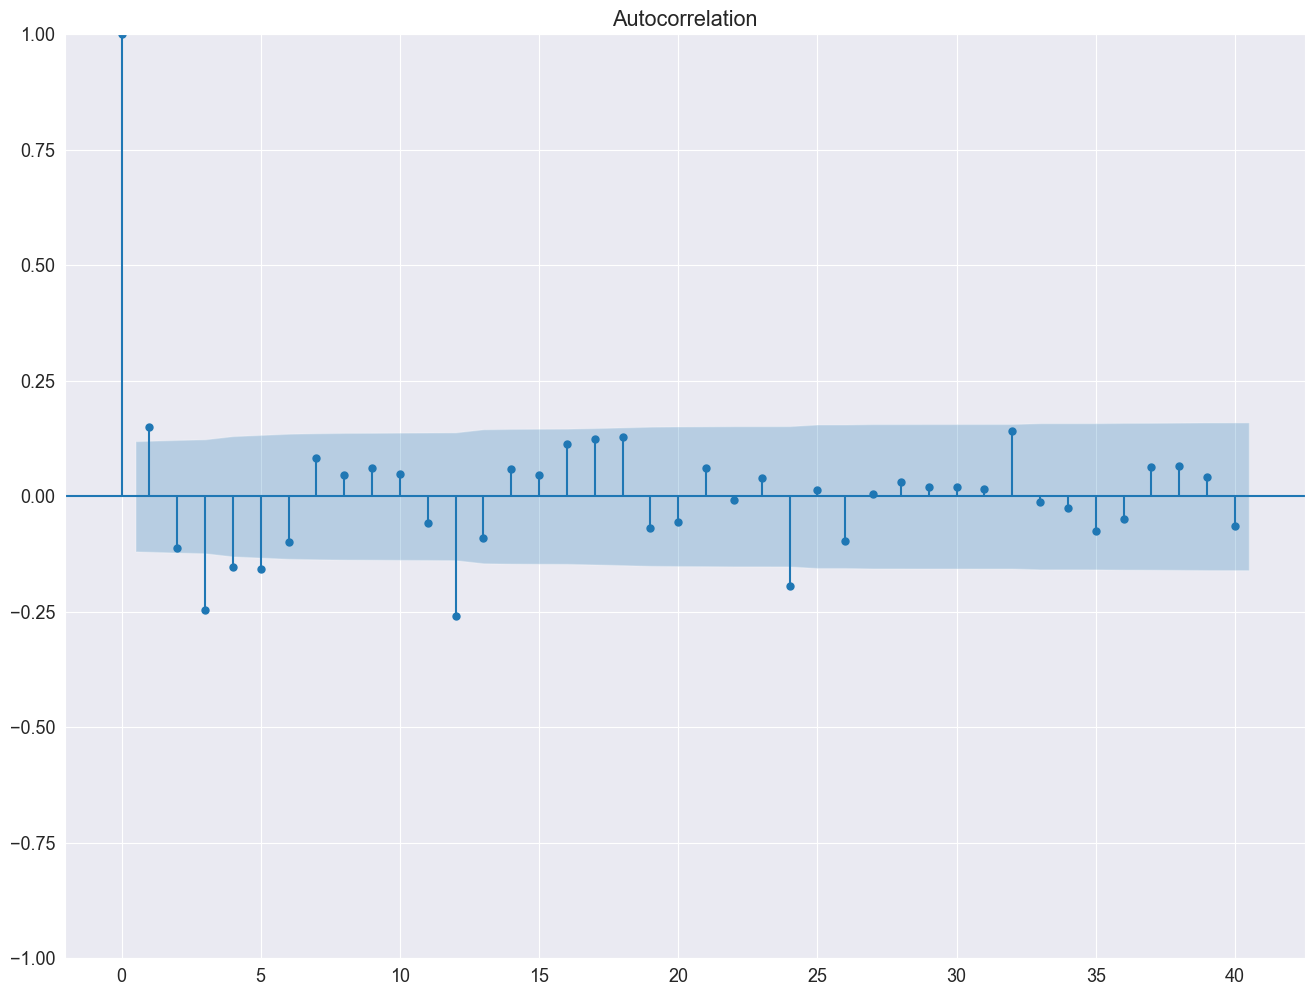

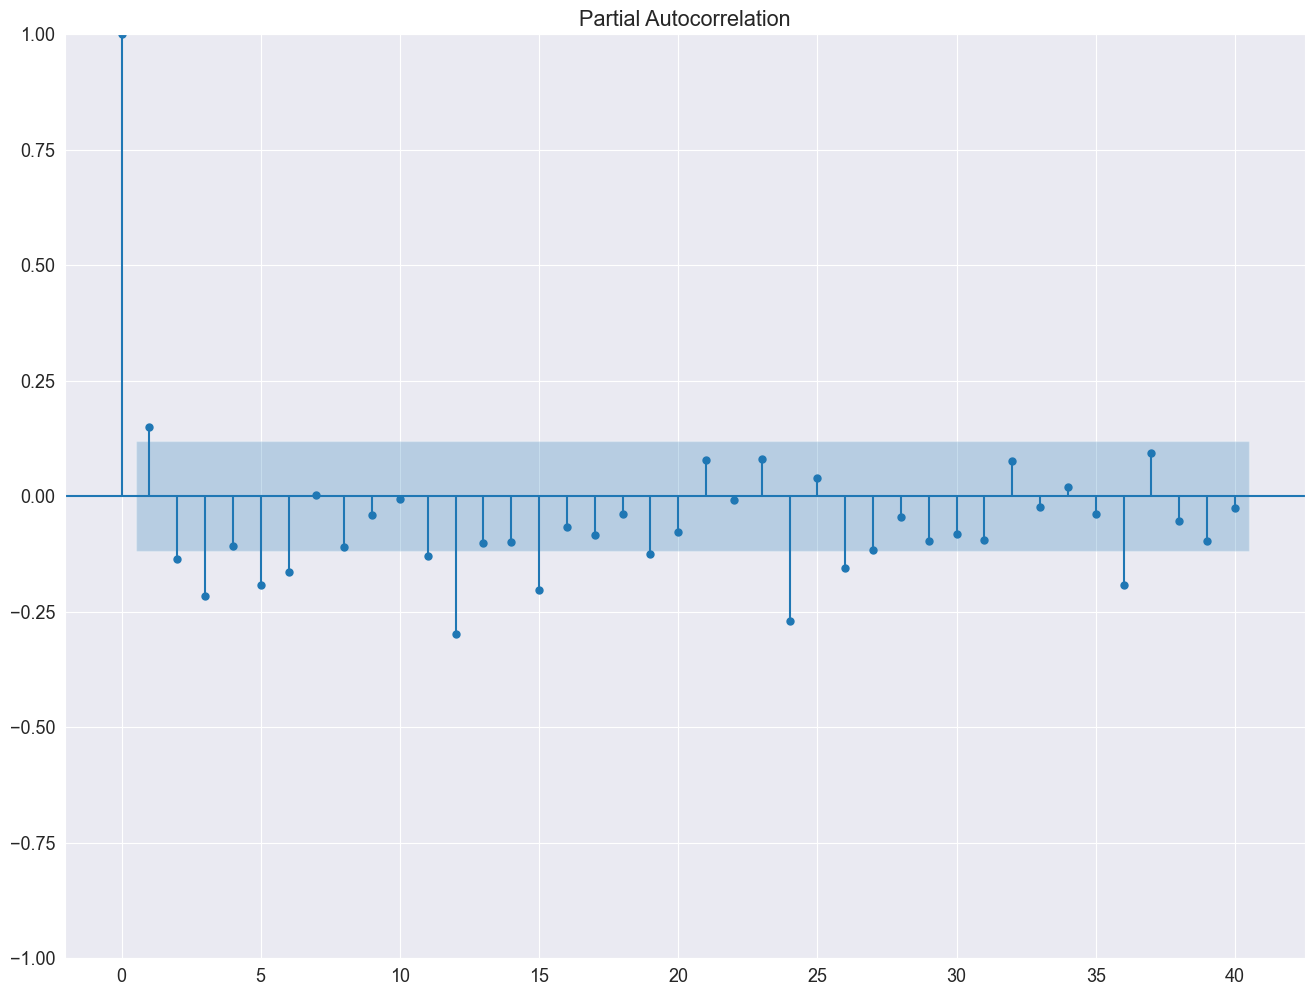

In [1192]:
# --- Your code here ---
plot_acf(residuals, lags=40)
plt.show()

plot_pacf(residuals, lags=40)
plt.show()

В основном лаги попали в доверительный интервал, но до сих пор есть пики в остатках на 1s,2s,3s и т.д

В остатках есть некая связь, которую возможно стоит учесть в дальнейшем анализе.


#### Задание 3.2: Прогнозирование с помощью простых моделей (1 балл)

Давайте теперь построим свой первый бейзлайн. Для тренда возьмем модель Хольта, для сезонности — наивный сезонный метод (**реализуйте его сами!**).

Для этого метода используем преобразованный ряд с оптимальным $\lambda$ из предыдущего задания.

In [1193]:
class NaiveSeasonal:
    def __init__(self, seasonal_period: int):
        # --- Your code here ---
        self.seasonal_period = seasonal_period
        self.last_season = None
        self.model_holt = None
        pass

    def fit(self, y: np.ndarray):
        # --- Your code here ---
        self.model_holt = ExponentialSmoothing(
            y, 
            trend='add', 
            seasonal=None
        ).fit()
        
        trend = self.model_holt.fittedvalues
        seasonal = y - trend        
        self.last_season = seasonal[-self.seasonal_period:]
        
        return {
            "model_holt": self.model_holt,
            "last_season": self.last_season
        }

    def predict(self, horizon: int) -> np.ndarray:
        steps = horizon  
        trend_forecast = self.model_holt.forecast(steps=steps)
        repeats = int(np.ceil(steps / self.seasonal_period))  
        seasonal_forecast = np.tile(self.last_season, repeats)[:steps]  
        return trend_forecast + seasonal_forecast   
        

Постройте прогноз на тестовую выборку.

In [1194]:
# --- Your code here ---
ets_model_naive = NaiveSeasonal(seasonal_period=12)  
ets_model_naive.fit(df_best_lam['y_transformed'].values)  

forecast_transformed = ets_model_naive.predict(horizon=30)  


Нарисуйте соответствующий график. На нем должна быть видна история из тренировочной выборки, тестовая выборка и прогноз. Не забудьте сделать обратное преобразование!

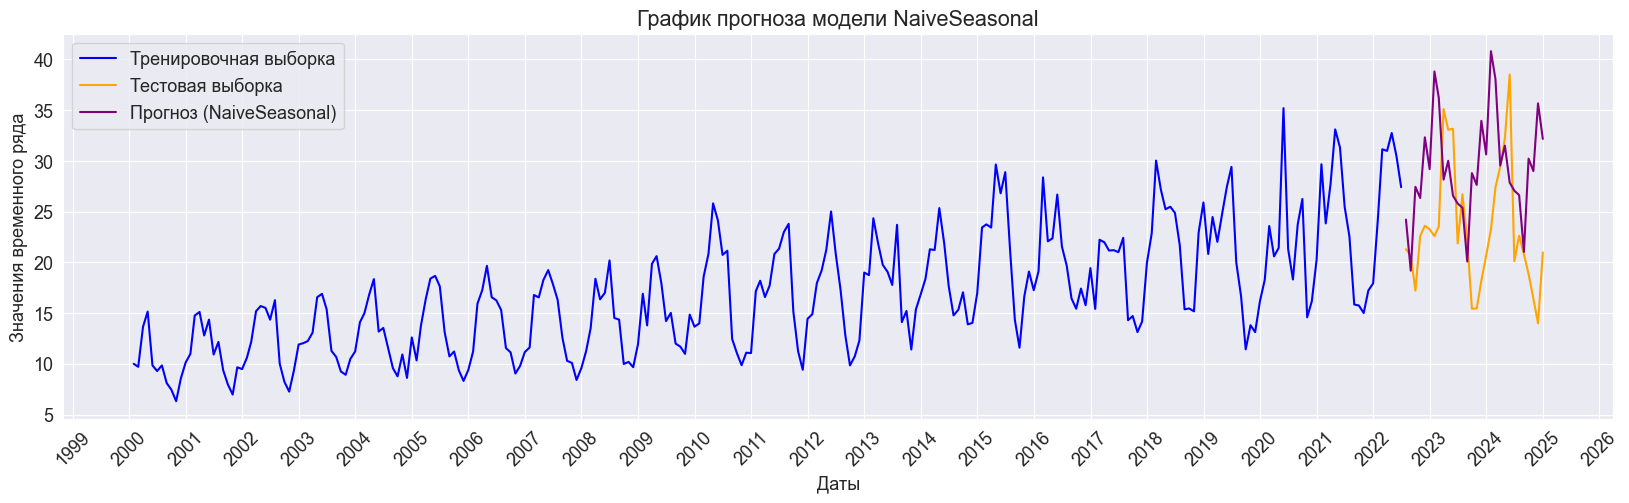

In [1195]:
forecast_original = inv_box_cox(forecast_transformed, lam_best) 
forecast_df = df_test.iloc[:len(forecast_original)].copy()
forecast_df['y'] = forecast_original

plt.figure(figsize=(20, 5))

plt.plot(df_train["date"], df_train["y"], label="Тренировочная выборка", color='blue')
plt.plot(df_test["date"], df_test["y"], label="Тестовая выборка", color='orange')
plt.plot(forecast_df["date"], forecast_df["y"], label="Прогноз (NaiveSeasonal)", color='purple')
plt.title("График прогноза модели NaiveSeasonal")
plt.xlabel("Даты")
plt.ylabel("Значения временного ряда")
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.grid(True)
plt.show()

#в графиках использую LLM для красивых стилей и наглядности, потому что у меня наслаивались слои и цвета я плохо подбирал

Оцените прогноз при помощи метрик MAE, MASE

In [1196]:
# --- Your code here ---

mae_score_naive = mae(forecast_df['y'].values,  df_test['y'].values)
mase_score_naive = mase(forecast_df['y'].values,  df_train['y'].values,  df_test['y'].values, 12)

print(f"MAE (Mean Absolute Error):       {mae_score_naive:.4f}")
print(f"MASE (Mean Absolute Scaled Error): {mase_score_naive:.4f}")

MAE (Mean Absolute Error):       8.1596
MASE (Mean Absolute Scaled Error): 2.8286


__Здесь и в дальнейшем складывайте все метрики в словарь / датафрейм / еще куда-нибудь для удобства сравнения.__

In [1197]:
model_metrics = {}

model_metrics['Naive Seasonal'] = {
    'MAE': mae_score_naive,
    'MASE': mase_score_naive
}


### Задание 4: ETS модель (1.5 балла)

Исходя из экспериментов с бейзлайном, выберите подходящую [ETS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.exponential_smoothing.ets.ETSModel.html) модель для ваших данных. Аргументируйте выбор.

__Обратите внимание, что моделировать нужно не преобразованный, а исходный ряд.__

Постройте прогноз на тестовую выборку.

In [1198]:
df_ets = df_init.copy()  
df_ets['date'] = pd.to_datetime(df_ets['date'])
df_ets = df_ets.set_index('date') #LLM помогла с проблемой - не работало - надо установить быдл индекс к дате

df_ets_test = df_test.copy()
df_ets_test['date'] = pd.to_datetime(df_ets_test['date'])
df_ets_test = df_ets_test.set_index('date')


In [1199]:
# --- Your code here ---

model = ETSModel(
    endog=df_ets['y'],
    freq='M',
    error='add',      
    trend='add',     
    seasonal='add',  
    seasonal_periods=12  
)

fitted_model = model.fit() 

forecast = fitted_model.forecast(steps=len(df_ets_test))



C:\Users\Albert13\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:595: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



Нарисуйте соответствующий график. На нем должна быть видна история из тренировочной выборки, тестовая выборка и прогноз.

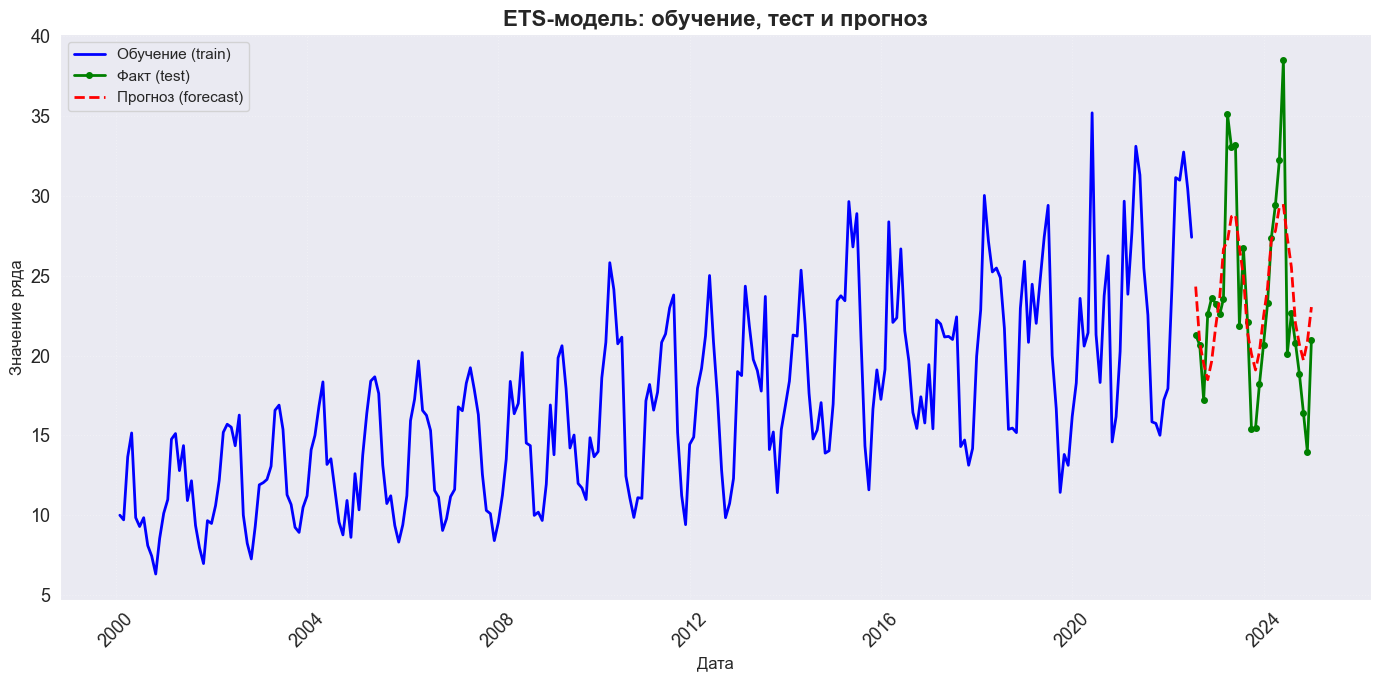

In [1200]:
train_data = df_ets['y']
test_data = df_ets_test['y']

if isinstance(forecast, np.ndarray):
    forecast = pd.Series(
        forecast,
        index=pd.date_range(
            start=test_data.index[0], 
            periods=len(forecast),
            freq='MS'  
        )
    )

plt.figure(figsize=(14, 7))

plt.plot(train_data.index, train_data, label='Обучение (train)', color='blue', linewidth=2)
plt.plot(test_data.index, test_data, label='Факт (test)', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(forecast.index, forecast, label='Прогноз (forecast)', color='red', linewidth=2, linestyle='--')

plt.title('ETS-модель: обучение, тест и прогноз', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Значение ряда', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle=':')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Оцените прогноз при помощи метрик MAE, MASE

In [1201]:
# --- Your code here ---

mae_score_ets = mae(forecast.values,  df_ets_test['y'].values)
mase_score_ets = mase(forecast.values,  df_ets['y'].values,  df_ets_test['y'].values, 12)

print(f"MAE (Mean Absolute Error):       {mae_score_ets:.4f}")
print(f"MASE (Mean Absolute Scaled Error): {mase_score_ets:.4f}")

MAE (Mean Absolute Error):       3.1830
MASE (Mean Absolute Scaled Error): 1.1034


In [1202]:
model_metrics['ETS'] = {
    'MAE': mae_score_ets,
    'MASE': mase_score_ets
}


Сравните вашу модель с тем, что выдает AutoETS из библиотеки [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/index.html). Удалось ли вам побить AutoETS?

In [1203]:
# --- Your code here ---

#узнал от llm что для AutoETS нужна колонка unique_id

train_data_sf = df_ets.reset_index()[["date", "y"]].rename(columns={"date": "ds"})
train_data_sf["unique_id"] = "series1" 

test_data_sf = df_ets_test.reset_index()[["date", "y"]].rename(columns={"date": "ds"})
test_data_sf["unique_id"] = "series1"

sf = StatsForecast(
    models=[AutoETS(model="AAA", season_length=12)],  
    freq="M", 
    n_jobs=1   
)

sf.fit(train_data_sf)

h = len(df_ets_test)
forecast_autoets = sf.predict(h=h)
y_pred_autoets = forecast_autoets["AutoETS"].values


mae_score_auto_ets = mae(y_pred_autoets,  df_ets_test['y'].values)
mase_score_auto_ets = mase(y_pred_autoets,  df_ets['y'].values,  df_ets_test['y'].values, 12)

print(f"MAE (Mean Absolute Error):       {mae_score_auto_ets:.4f}")
print(f"MASE (Mean Absolute Scaled Error): {mase_score_auto_ets:.4f}")

model_metrics['ETS-AUTO'] = {
    'MAE': mae_score_auto_ets,
    'MASE': mase_score_auto_ets
}

MAE (Mean Absolute Error):       3.2322
MASE (Mean Absolute Scaled Error): 1.1204


C:\Users\Albert13\miniconda3\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\Albert13\miniconda3\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



Подсказка: скорее всего у вас не получилось:) 

Если хотите побить AutoETS, попробуйте обратить внимание на вид остатков.

### Задание 5: ARIMA модель (4 балла)

Самое время для SARIMA! Задание довольно сложное, поэтому мы готовы дать за него большое количество баллов. Мы в вас верим!

Пользуясь правилами [отсюда](https://docs.google.com/document/d/1wVsBkRIZbHdPMQIbUoXdznrmxkSZNEVFLq9D_OzCldA/edit?tab=t.0), подберите параметры [SARIMA](https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima.model.ARIMA.html) модели, как мы делали это на занятии.

__Не забудьте, что здесь снова нужно моделировать преобразованный рядом с оптимальным $\lambda$ из задания 2.__

Помните, что начинаем мы с анализа сезонности и тренда, а затем уже подбираем параметры p, q, P, Q. И помните, что вам нужно будет несколько раз возвращаться к построению ACF, PACF графиков остатков, чтобы понять, хорошо ли вы смоделировали ряд. При правильно подобранных параметрах в остатках не должно быть автокорреляции и они должны проходить тесты на стационарность. 

<Figure size 1000x600 with 0 Axes>

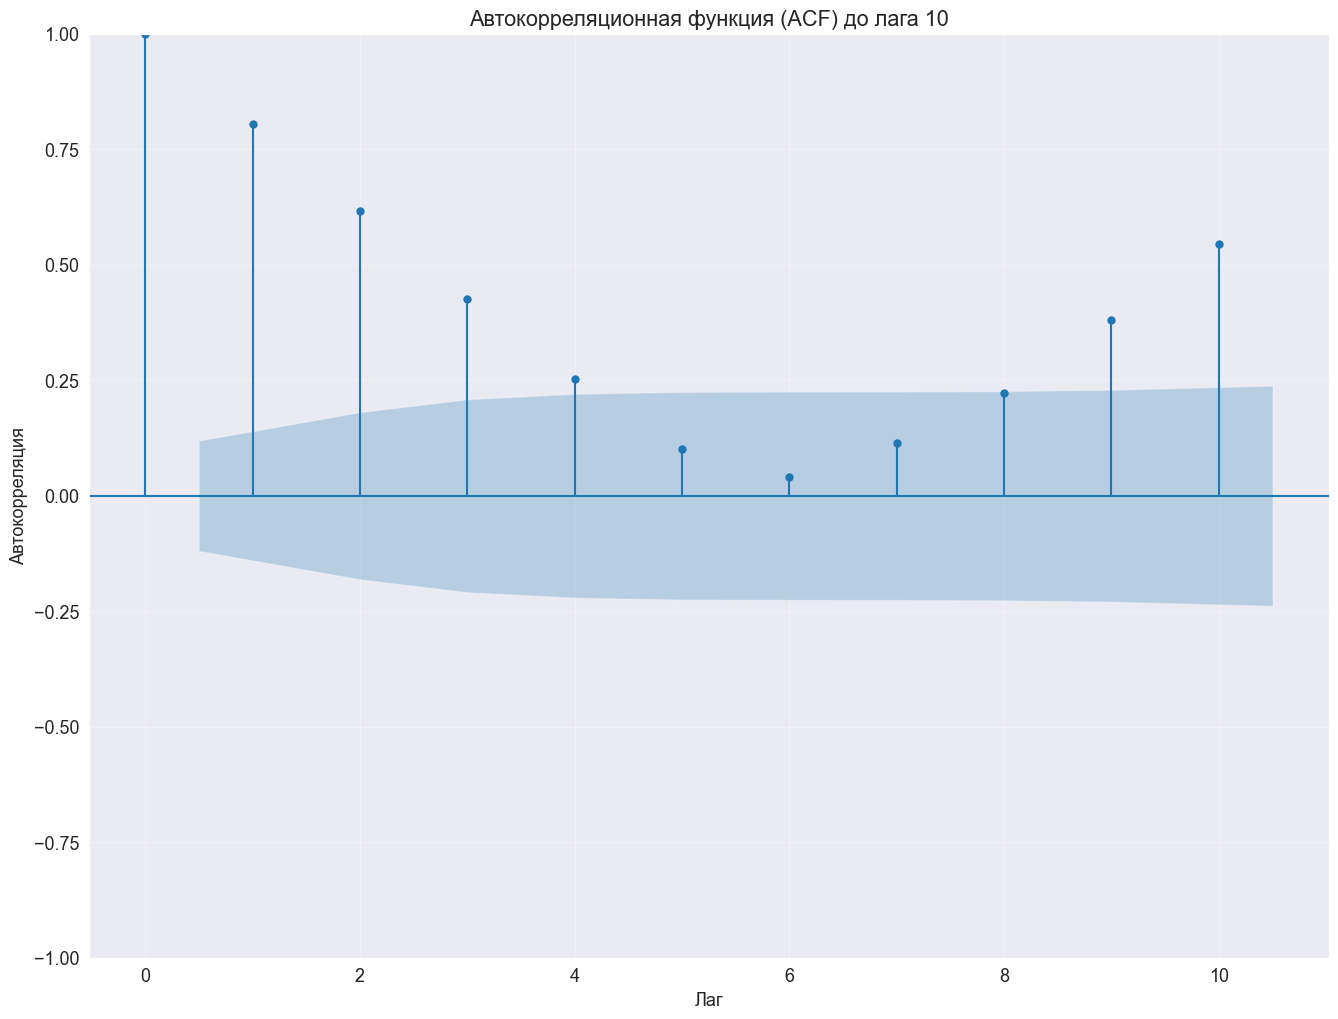

<Figure size 1000x600 with 0 Axes>

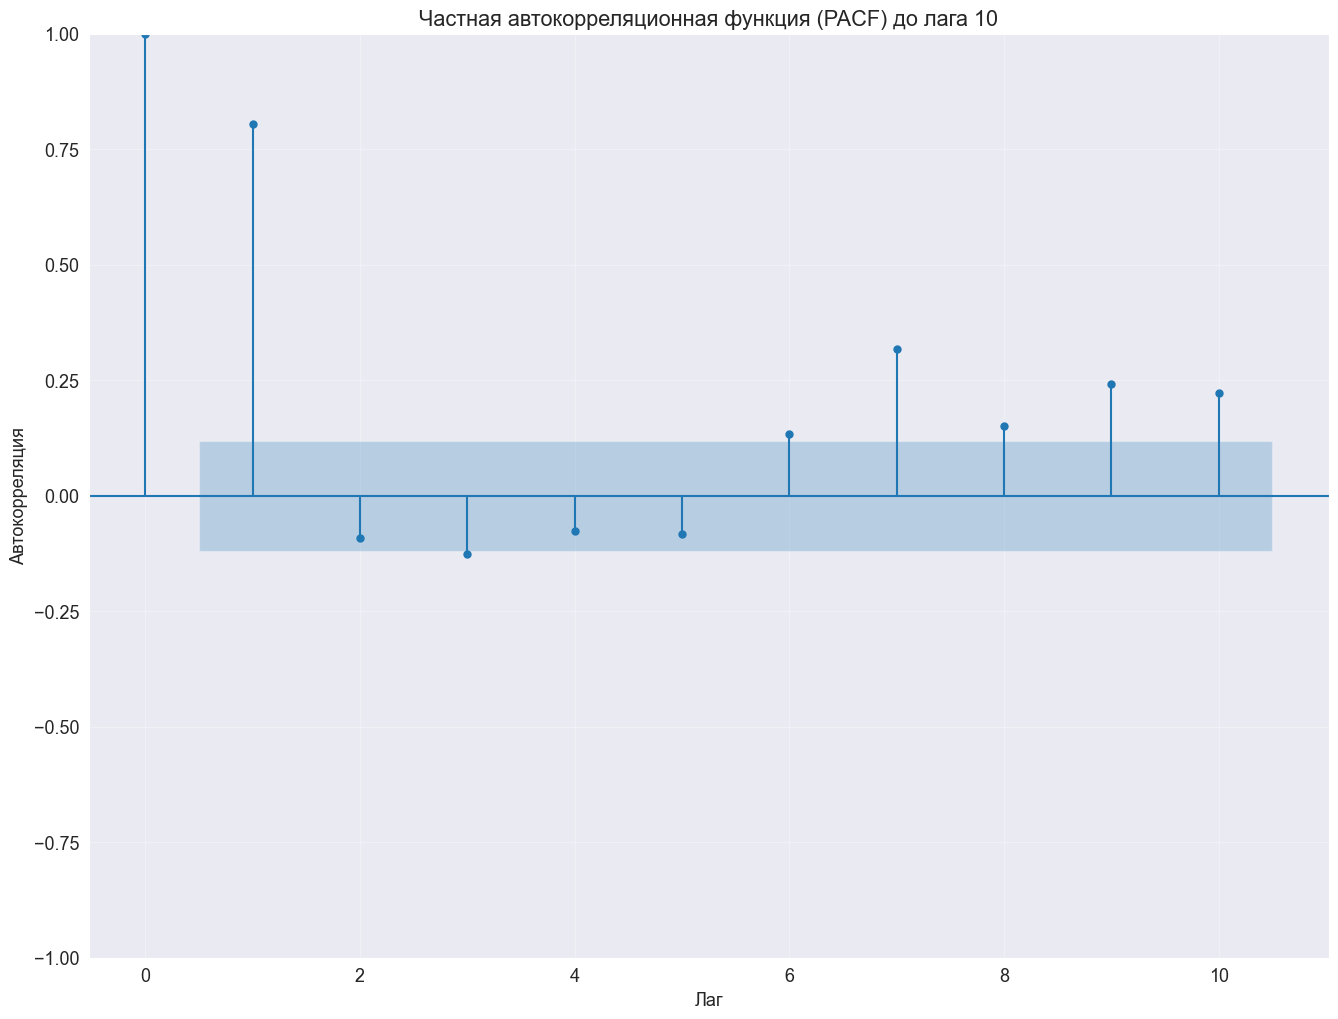

Результаты теста ADF:
Test Statistic     -0.888205
p-value             0.791832
#Lags Used         12.000000
Observations      257.000000
dtype: float64
Нестационарен при d = 0. Пробуем d = 1

Оптимальный порядок: d = 1


In [1204]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

#ПОПРАВИЛ С LLM ФУНКЦИЯ ДЛЯ ПОДБОР ПОРЯДКА ДИФФЕРЕНЦИРОВАНИЯ 
def test_adf(series, max_d=2):
    for d in range(max_d + 1):
        if d > 0:
            series_diff = np.diff(series, n=d)
        else:
            series_diff = series
        
        result = adfuller(series_diff)
        
        if result[1] < 0.05:
            return d
        else:
            print(f"Нестационарен при d = {d}. Пробуем d = {d+1}\n")
    
    return None

plt.figure(figsize=(10, 6))
plot_acf(df_best_lam['y'], lags=10, alpha=0.05)
plt.title('Автокорреляционная функция (ACF) до лага 10')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))
plot_pacf(df_best_lam['y'], lags=10, alpha=0.05)
plt.title('Частная автокорреляционная функция (PACF) до лага 10')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.grid(True, alpha=0.3)
plt.show()


adf_test(df_best_lam['y'])
d_optimal = test_adf(df_best_lam['y'], max_d=2)

if d_optimal is not None:
    print(f"Оптимальный порядок: d = {d_optimal}")
else:
    print("Не нашли порядок дифференцирования.")

<Figure size 1000x600 with 0 Axes>

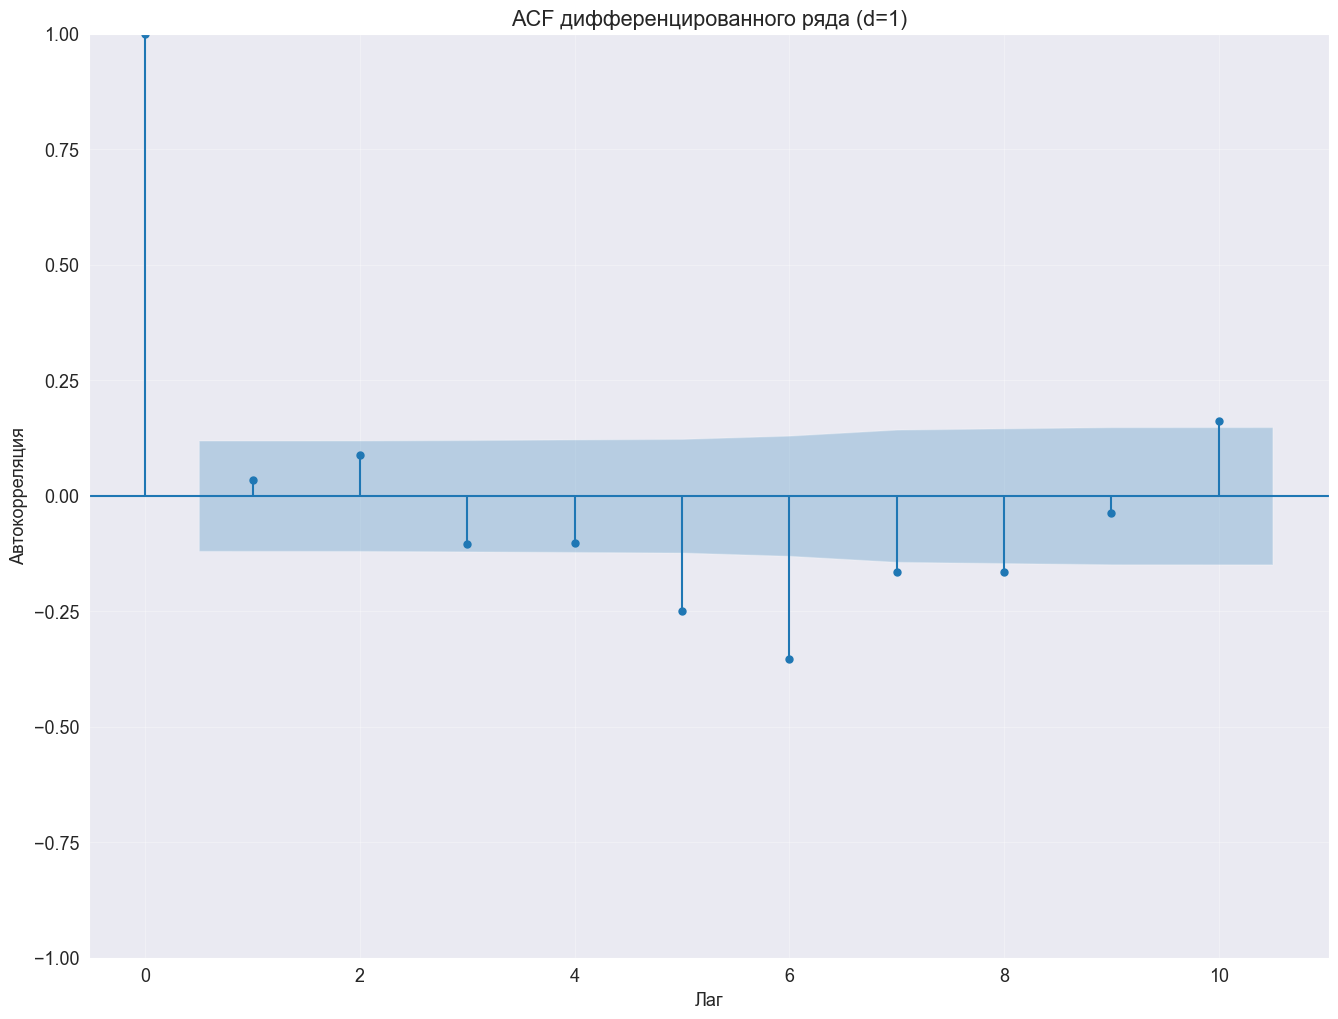

<Figure size 1000x600 with 0 Axes>

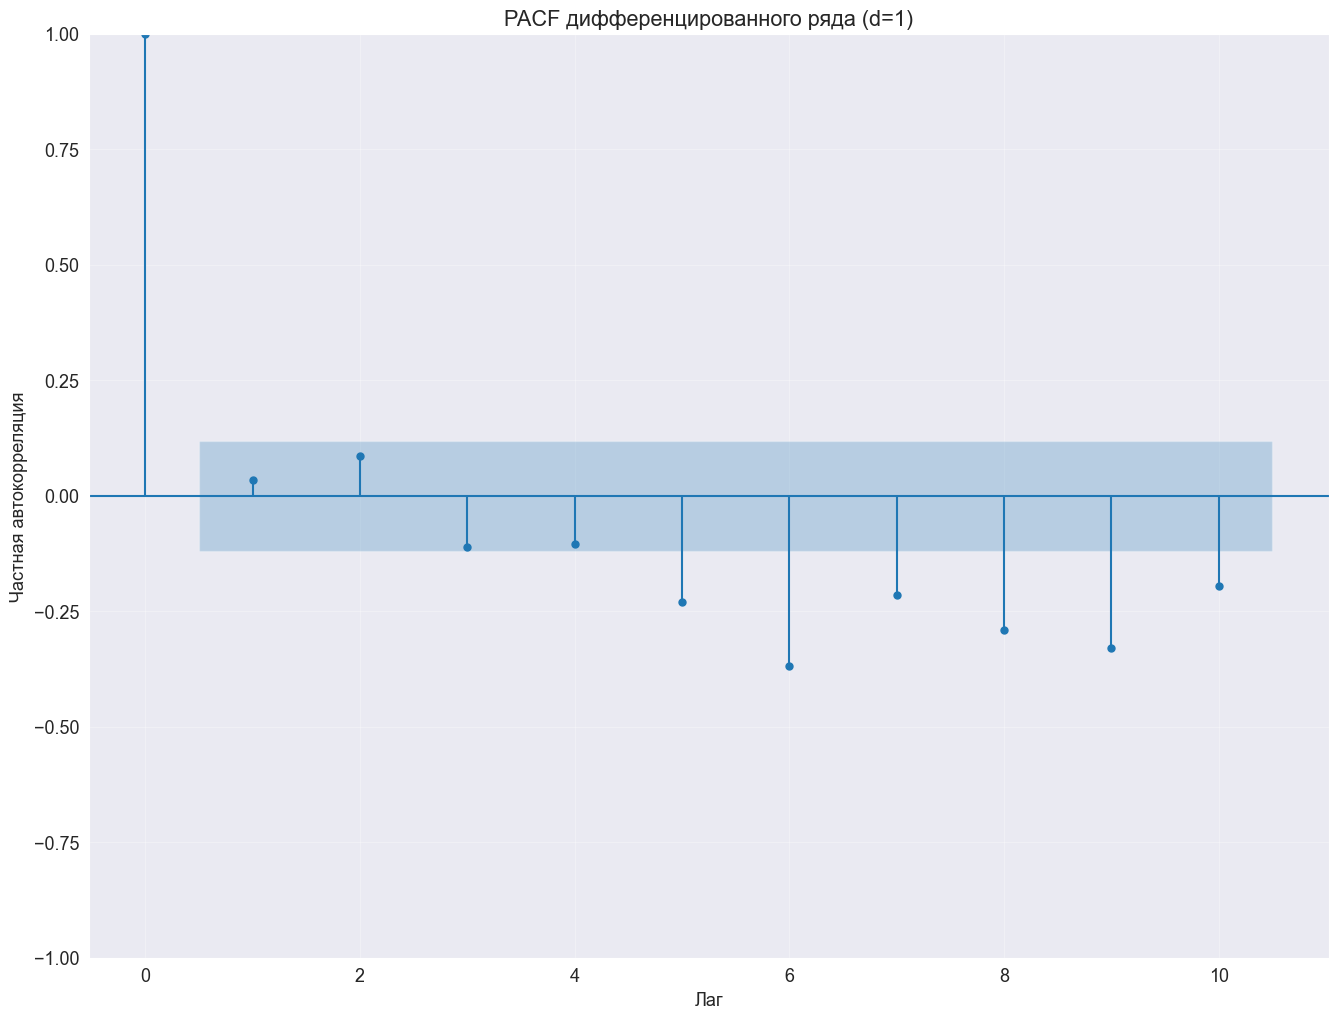

In [1205]:
y_diff = np.diff(df_best_lam['y_transformed'], n=d_optimal)

plt.figure(figsize=(10, 6))
plot_acf(y_diff, lags=10, alpha=0.05)
plt.title(f'ACF дифференцированного ряда (d={d_optimal})')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plot_pacf(y_diff, lags=10, alpha=0.05)
plt.title(f'PACF дифференцированного ряда (d={d_optimal})')
plt.xlabel('Лаг')
plt.ylabel('Частная автокорреляция')
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1200x600 with 0 Axes>

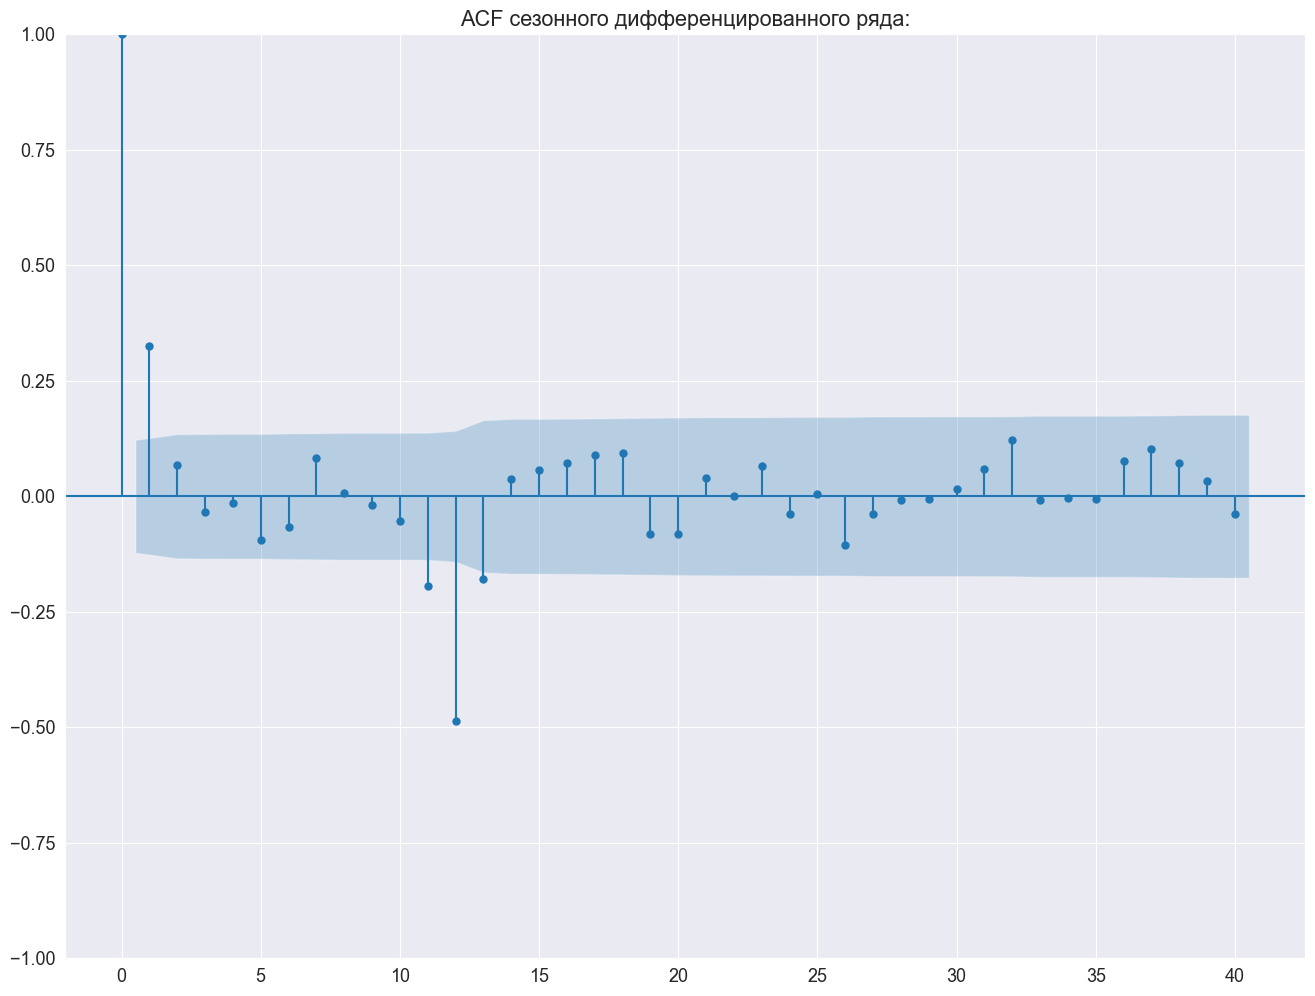

<Figure size 1200x600 with 0 Axes>

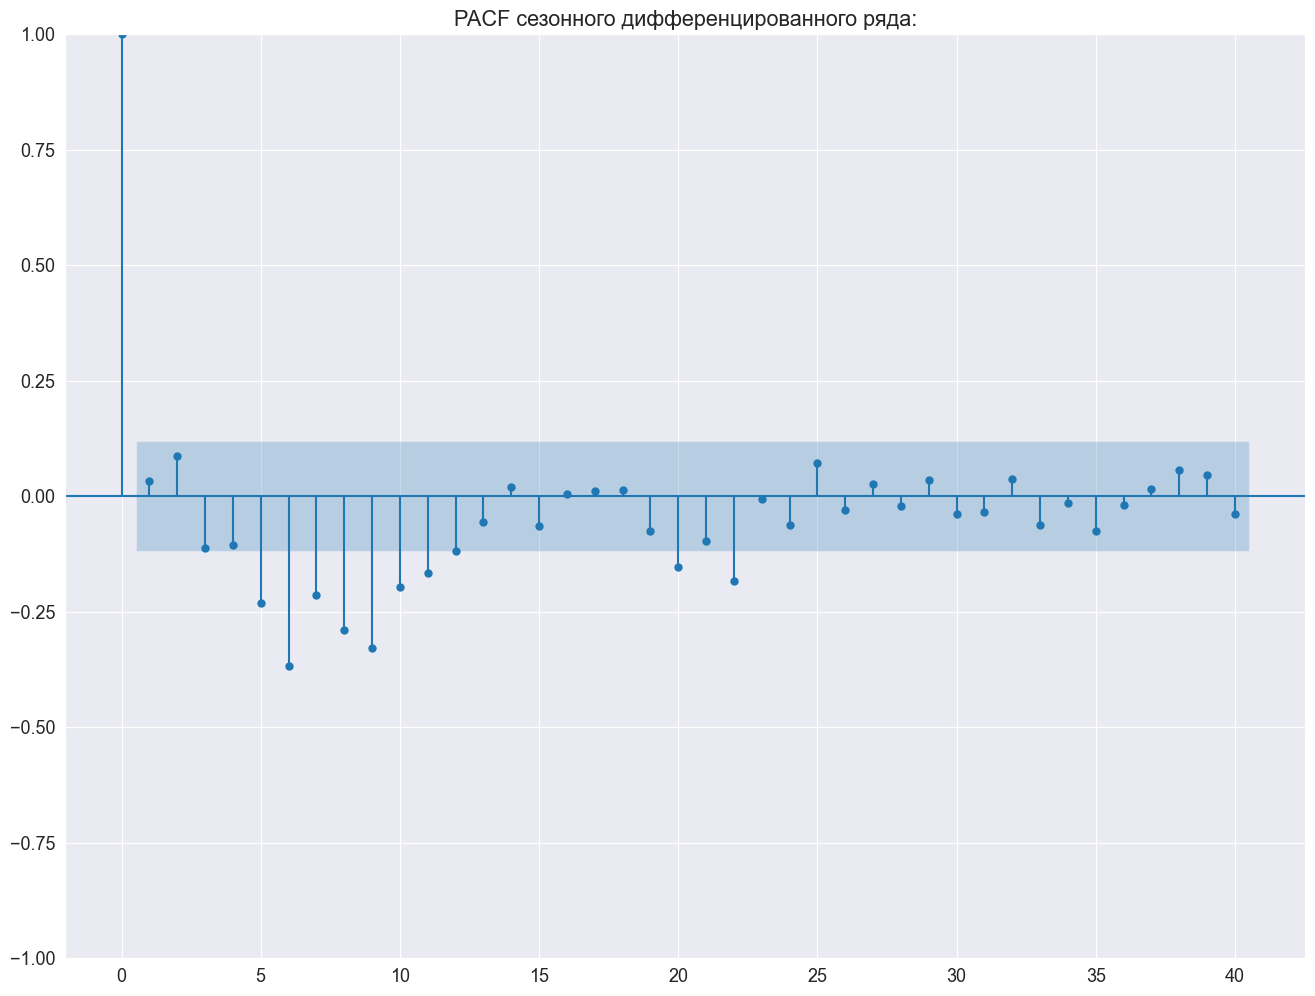

In [1206]:
y_seas_diff = df_best_lam['y_transformed'].diff(periods=12).dropna()

plt.figure(figsize=(12, 6))
plot_acf(y_seas_diff, lags=min(40, len(y_seas_diff)//2), alpha=0.05)
plt.title(f'ACF сезонного дифференцированного ряда:')
plt.show()


plt.figure(figsize=(12, 6))
plot_pacf(y_diff, lags=min(40, len(y_diff)//2), alpha=0.05)
plt.title(f'PACF сезонного дифференцированного ряда:')
plt.show()


По итогу исследования:
1. Для order: подобрали d=1 - написали функцию, которая идет к уменьшению p-value ошибки меньше 0.05, для p и q визуализировали графики PACF и ACF продиффиренцированного ряда, чтоб исходя из правил посмотреть, где "резко" обрываются значения: из графиков видно, что PACF и ACF обрываются после первых лагов. В итоге получаем, d=1,p=1,q=1.
2. Для seasonal order - провели сезонное дифферецнирование - так как в предыдущих шагах получали и видели на график сезонность 12, берем d = 1, так как для устойчивой сезонности порядок дифференцирования равный 1 - нормальное значение. После начертили PACF и ACF для сезонно-продифференцированных графиков - получили по одному значимому лагу - на acf сохранилась корреляция на лаге 1s=12, берем q = 1, а на pacf корреляция пропала - оставляем = 0. В итоге получаем, p=0,d=1,q=1,s=12.

In [1207]:
model = ARIMA(endog=df_best_lam['y_transformed'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12), trend=None)
model_fit = model.fit()
pred = inv_box_cox(model_fit.forecast(len(df_test)), -0.125)
forecast_sarima = df_test.copy()
forecast_sarima.iloc[:, 1] = pred


Нарисуйте соответствующий график. На нем должна быть видна история из тренировочной выборки, тестовая выборка и прогноз.

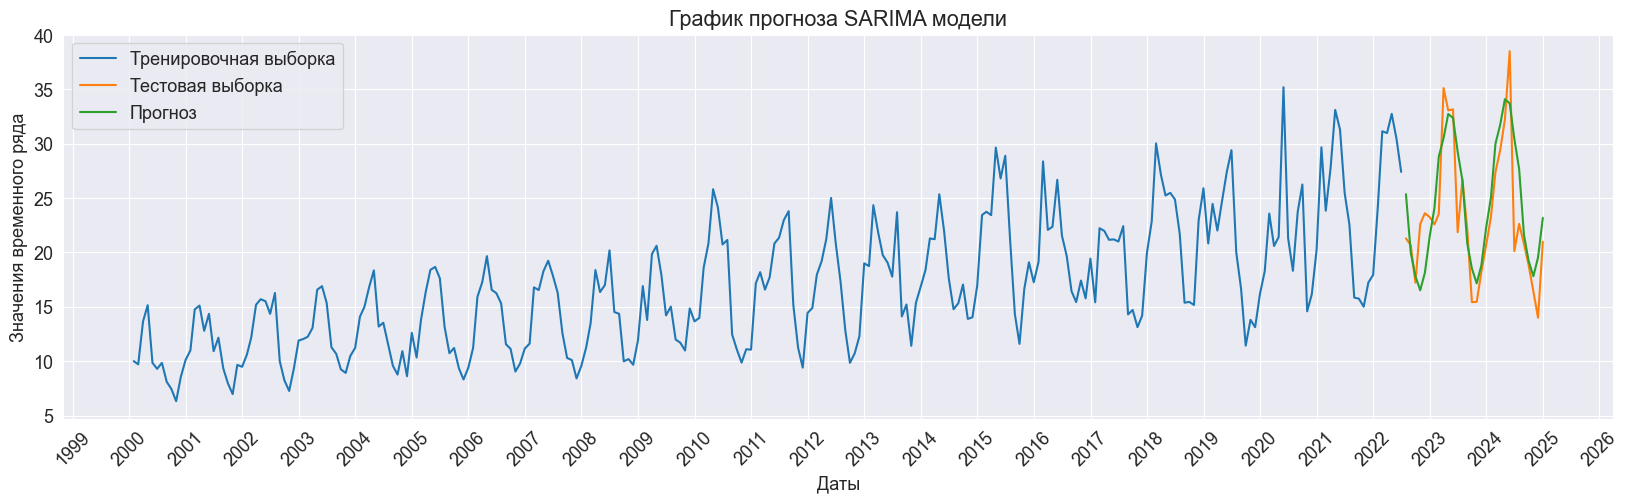

In [1208]:
plt.figure(figsize=(20, 5))
plt.plot(df_init["date"], df_init["y"], label="Тренировочная выборка")
plt.plot(df_test["date"], df_test["y"], label="Тестовая выборка")
plt.plot(forecast_sarima["date"], forecast_sarima["y"], label="Прогноз")
plt.title(f"График прогноза SARIMA модели")
plt.xlabel("Даты")
plt.ylabel("Значения временного ряда")
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.grid(True)
plt.show()

Оцените прогноз при помощи метрик MAE, MASE

In [1209]:
# --- Your code here ---

mae_score_sarima = mae(forecast_sarima['y'].values,  df_ets_test['y'].values)
mase_score_sarima = mase(forecast_sarima['y'].values,  df_ets['y'].values,  df_ets_test['y'].values, 12)

print(f"MAE (Mean Absolute Error):       {mae_score_sarima:.4f}")
print(f"MASE (Mean Absolute Scaled Error): {mase_score_sarima:.4f}")

MAE (Mean Absolute Error):       2.8734
MASE (Mean Absolute Scaled Error): 0.9961


In [1210]:
model_metrics['ARIMA'] = {
    'MAE': mae_score_sarima,
    'MASE': mase_score_sarima
}


Сравните вашу модель с тем, что выдает AutoARIMA из библиотеки [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/index.html). Удалось ли вам побить AutoARIMA?

In [1211]:
# Ваши данные
df_train_auto = df_best_lam[['date', 'y_transformed']].copy()  
df_test = df_test.copy()                                
horizon = len(df_test)
s = 12  

df_sf = df_train_auto[['date', 'y_transformed']].copy()
df_sf.columns = ['ds', 'y']
df_sf['ds'] = pd.to_datetime(df_sf['ds'])
df_sf['unique_id'] = 'series_1'  

auto_model = AutoARIMA(
    season_length=s,
    trace=True,
    stepwise=False,         
    approximation=False,        
    max_p=5, max_q=5,       
    max_P=2, max_Q=2,       
    max_d=2, max_D=1,       
    method='statespace'        
)
sf = StatsForecast(models=[auto_model], freq='MS') 
sf.fit(df_sf)

forecast_auto = sf.predict(horizon)
pred_auto = forecast_auto['AutoARIMA']




ARIMA(0,0,0)(0,1,0)[12]                   :-244.09715875508476

ARIMA(0,0,0)(0,1,0)[12] with drift        :-251.41807338169815

ARIMA(0,0,0)(0,1,1)[12]                   :-242.06572493155534

ARIMA(0,0,0)(0,1,1)[12] with drift        :-249.3706440162512

ARIMA(0,0,0)(0,1,2)[12]                   :-240.01829556610838

ARIMA(0,0,0)(0,1,2)[12] with drift        :-247.30702943842917

ARIMA(0,0,0)(1,1,0)[12]                   :-242.06572493155534

ARIMA(0,0,0)(1,1,0)[12] with drift        :-249.3706440162512

ARIMA(0,0,0)(1,1,1)[12]                   :-240.01829556610838

ARIMA(0,0,0)(1,1,1)[12] with drift        :-247.30702943842917

ARIMA(0,0,0)(1,1,2)[12]                   :-237.95468098828636

ARIMA(0,0,0)(1,1,2)[12] with drift        :-245.22703696713234

ARIMA(0,0,0)(2,1,0)[12]                   :-240.01829556610838

ARIMA(0,0,0)(2,1,0)[12] with drift        :-247.30702943842917

ARIMA(0,0,0)(2,1,1)[12]                   :-237.95468098828636

ARIMA(0,0,0)(2,1,1)[12] with drift       

---

Соберите все полученные метрики (и от автоматических решений тоже) в одну таблицу для удобства сравнения.

In [1212]:
y_true = df_test['y'].values  
forecast_sarima_auto = inv_box_cox(forecast_auto['AutoARIMA'].values, -0.125)

mae_sarima_auto = mae(forecast_sarima_auto, y_true)
mase_sarima_auto = mase(forecast_sarima_auto, df_init['y'].values, y_true, s)

print(f"MAE:  {mae_sarima_auto:.4f}")
print(f"MASE: {mase_sarima_auto:.4f}")

model_metrics['ARIMA-AUTO'] = {
    'MAE': mae_sarima_auto,
    'MASE': mase_sarima_auto
}

MAE:  3.5318
MASE: 1.2243


`Бонус (0.5 баллов):` Добавьте в эту таблицу метрики бейзлайнов: последнее значение и прогноз модели SES.

In [1213]:
ses_model = ExponentialSmoothing(
    endog=df_best_lam['y_transformed'],
    trend=None,
    seasonal=None,
    damped_trend=False
)
ses_fit = ses_model.fit()
forecast_ses_transformed = ses_fit.forecast(len(df_test))
forecast_ses = inv_box_cox(forecast_ses_transformed, lam_best)
mae_ses = mae(forecast_ses, y_true)
mase_ses = mase(forecast_ses, df_init['y'].values, y_true, s)

model_metrics['SES'] = {
    'MAE': mae_ses,
    'MASE': mase_ses
}


In [1214]:
sorted_items = sorted(model_metrics.items(), key=lambda x: x[1]['MAE'])
print(f"{'Название модели':<15} {'MAE':<10} {'MASE':<10}")

for model, metrics in sorted_items:
    print(f"{model:<15} {metrics['MAE']:<10.4f} {metrics['MASE']:<10.4f}")


Название модели MAE        MASE      
ARIMA           2.8734     0.9961    
ETS             3.1830     1.1034    
ETS-AUTO        3.2322     1.1204    
ARIMA-AUTO      3.5318     1.2243    
SES             6.5081     2.2561    
Naive Seasonal  8.1596     2.8286    


Какая модель показала наилучший результат? Удалось ли побить самые простые модели? А автоматические методы?

Лучший результат у ARIMA модели - возможно это логично, потому что мы сами вручную все проанализировали и своими руками вывели каждый коэффициент.
Автоматические модели дали метрики чуть хуже - это мне не до конца понятно, потому что мои параметры внутри они же тоже должны были перебрать, но видимо там надо будет еще в будущем поиграть с параметрами. А вот простую наивную модель победить удалось, Naive Seasonal оказалось самой слабой по качеству.

### БОНУС: Улучшите ваше решение из прошлых заданий (до 2-х бонусных баллов)

Скомбинируйте методы: сезонность из STL, ARIMA на всем остальном (или только на остатках). Либо же ETS на всем ряде + ARIMA на остатках. Будет еще круче, если вы попробуете что-то свое. Можете попробовать другие модели (Prophet, Theta, ...), но не лезьте пока что в сторону машинного обучения.

In [1228]:

# НАПИСАЛ ПОЛНОСТЬЮ С LLM было интересно просто насколько результат будет хорош, в целом он неплох - параметры для ARIMA сначала подобрал через автоматическую ARIMA 

df_serie = df_best_lam.set_index('date')['y_transformed']
stl = STL(df_serie, seasonal=13)
result = stl.fit()


trend = result.trend
seasonal = result.seasonal
residuals = result.resid

arima_model = ARIMA(residuals, order=(3, 1, 0), seasonal_order=(2, 1, 0, 12))
arima_fit = arima_model.fit()
residuals_forecast = arima_fit.forecast(steps=h)

from sklearn.linear_model import LinearRegression
N = min(24, len(trend))
X = np.arange(N).reshape(-1, 1)
y = trend[-N:].values
model = LinearRegression().fit(X, y)
X_pred = np.arange(N, N + h).reshape(-1, 1)
trend_forecast = model.predict(X_pred)

full_cycle = seasonal[-12:].values
seasonal_forecast = np.concatenate([full_cycle] * (h // 12 + 1))[:h]

transformed_forecast = trend_forecast + seasonal_forecast + residuals_forecast

best_lambda = -0.125

if best_lambda == 0:
    final_forecast = np.exp(transformed_forecast)
else:
    final_forecast = (transformed_forecast * best_lambda + 1) ** (1 / best_lambda)

mae = np.mean(np.abs(y_true - final_forecast))
mase = mae / np.mean(np.abs(np.diff(df_init['y'].values)))
print(f"MAE: {mae:.4f}, MASE: {mase:.4f}")

C:\Users\Albert13\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.

C:\Users\Albert13\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.

C:\Users\Albert13\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.



MAE: 2.8424, MASE: 1.0538


### БОНУС: Повторите задания из этого ноутбука на реальном датасете (до 4-х бонусных баллов)

Баллы за это задание ставится при условии, что вы подробно опишите, что вы делали и почему И если вы побили Auto-ETS и Auto-ARIMA модели на отложенном тесте в 10% точек.

Будем работать с датасетом `NN5`, который можно скачать [здесь](https://zenodo.org/records/4656117). Временные ряды в этом датасете представляют собой данные по ежедневным снятиям наличных в банкоматах в Великобритании. 

Заберем из него ряд под номером 92.

In [1133]:
df_real = pd.read_csv("nn5.csv")
df_real = df_real[df_real["id"] == 92]

FileNotFoundError: [Errno 2] No such file or directory: 'nn5.csv'

In [ ]:
# --- Your code here ---